# Background (Elevator Pitch)

Note**

 We want to develop a loan approval prediction model that can correctly predict the likelihood of approval of loans to potential borrowers. This model will help the banks make more informed decisions regarding loan applications, thereby reducing the risk of defaults and enhancing their lending efficiency. Accurate prediction of loan approval can have a wide impact on the lending operations of any bank by: Reducing loan defaults by identifying high-risk borrowers, Smoothing the process of loan approval, Increasing customer satisfaction with quicker and more accurate decisions, Targeted marketing and customer segmentation. We will develop a machine learning model that uses demographic, credit, and loan-related information to predict loan outcomes. In our model, we will incorporate all the various factors for comprehensive and accurate prediction. Our data science approach involves: Thorough EDA to understand the relationships between various factors and loan approval outcomes, Feature engineering to create meaningful and predictive variables, Model selection and evaluation to identify the best performing model, Continuous improvement through model updates and fine-tuning. It will reduce the risks related to loan defaults and can save enormous amounts of money. Our idea will improve the efficiency of the loan approval process and thereby make the bank capable of serving a large number of customers and increasing revenue. It will increase customer satisfaction and trust through faster and more accurate decisions. Finally, it will drive competitiveness in the market by proposing innovative and data-driven solutions.

https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data

In [2]:
import pandas as pd
import numpy as np
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [3]:
df = pd.read_csv('loan_data.csv')

In [4]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [5]:
df.columns = ['Age', 'Sex', 'Education Level', 'Income', 'Employment Years', 'Home Ownership', 'Loan Amount', 'Loan Intent',
              'Interest Rate', 'Percentage of Income', 'Years of Credit History', 'Credit Score', 'Defaults', 'Status']

# Data Exploration

In [6]:
df.shape

(45000, 14)

<Axes: >

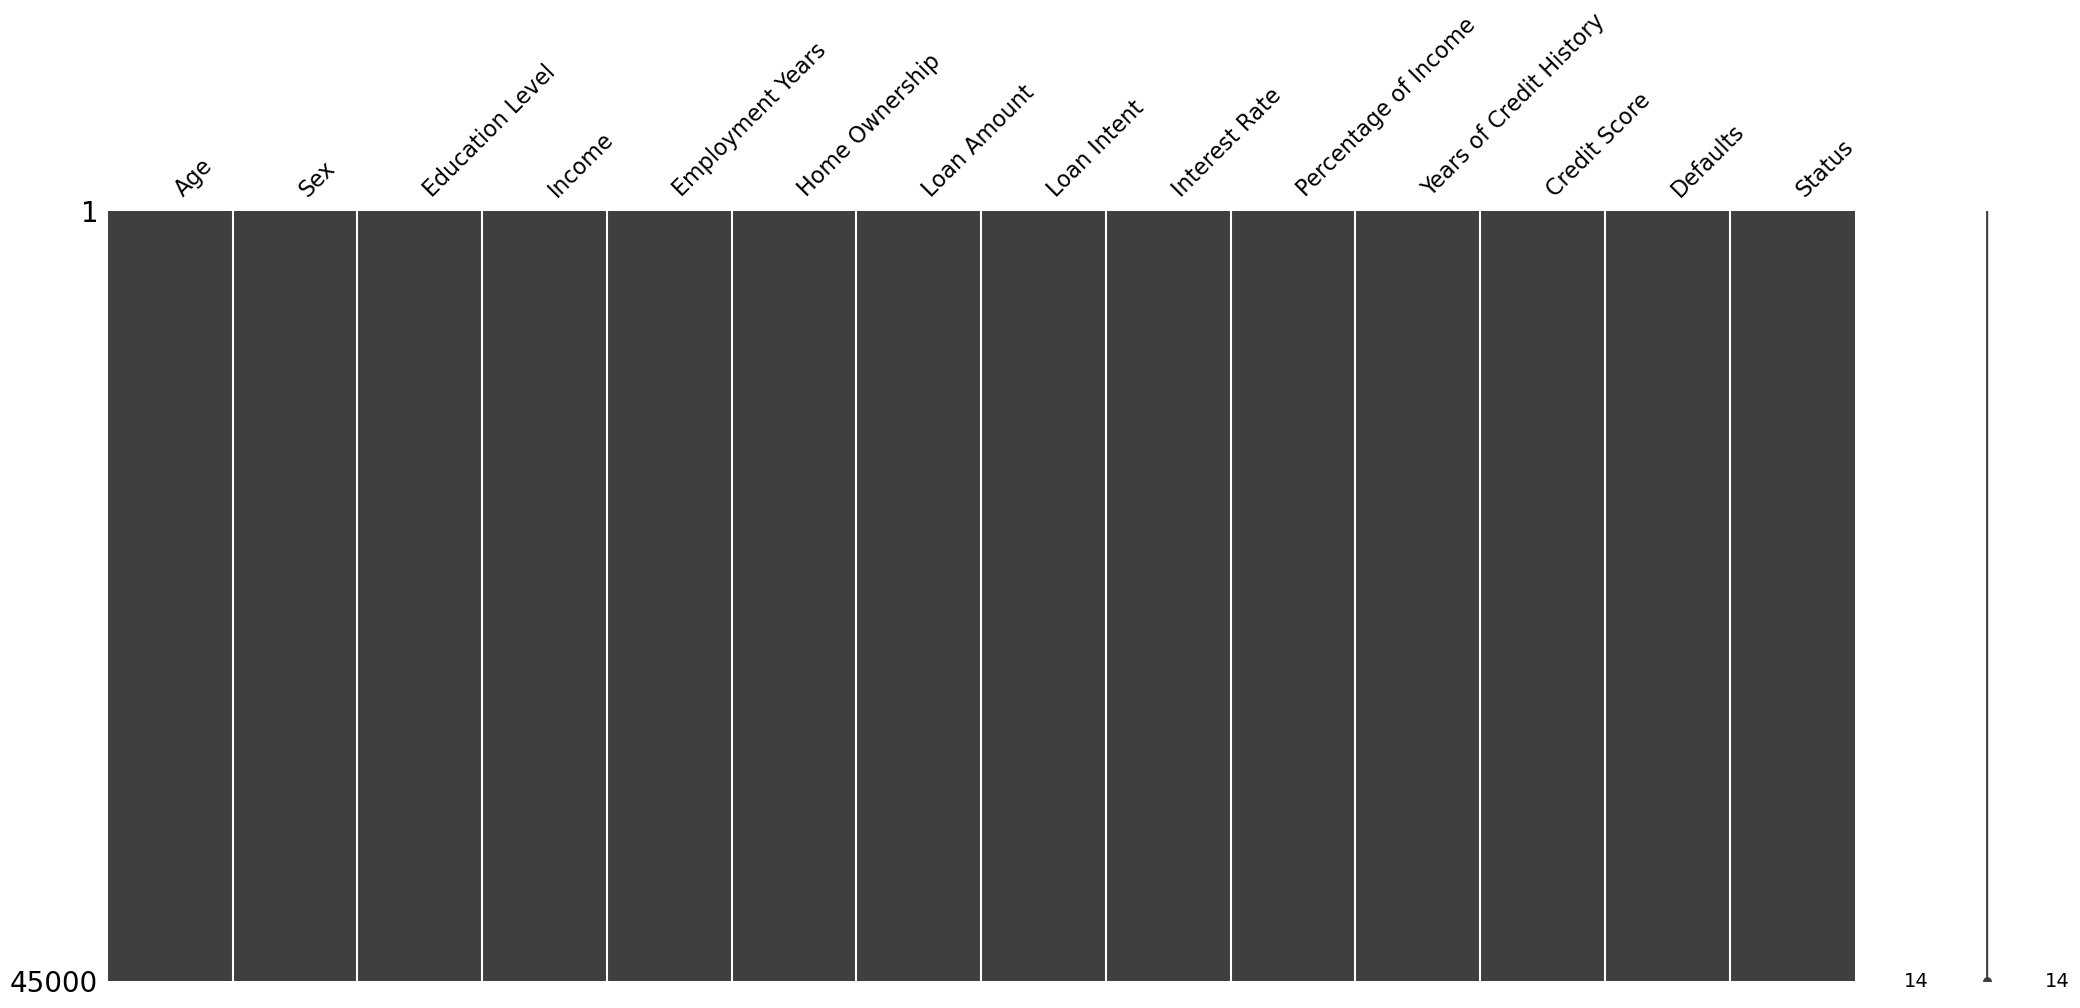

In [7]:
msno.matrix(df)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      45000 non-null  float64
 1   Sex                      45000 non-null  object 
 2   Education Level          45000 non-null  object 
 3   Income                   45000 non-null  float64
 4   Employment Years         45000 non-null  int64  
 5   Home Ownership           45000 non-null  object 
 6   Loan Amount              45000 non-null  float64
 7   Loan Intent              45000 non-null  object 
 8   Interest Rate            45000 non-null  float64
 9   Percentage of Income     45000 non-null  float64
 10  Years of Credit History  45000 non-null  float64
 11  Credit Score             45000 non-null  int64  
 12  Defaults                 45000 non-null  object 
 13  Status                   45000 non-null  int64  
dtypes: float64(6), int64(3

In [9]:
df['Defaults'] = df['Defaults'].replace({'Yes': 1, 'No': 0})
df['Defaults'] = df['Defaults'].astype(int)

C:\Users\jtlax\AppData\Local\Temp\ipykernel_27668\1582302674.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Defaults'] = df['Defaults'].replace({'Yes': 1, 'No': 0})


In [10]:
df.describe()

,Age,Income,Employment Years,Loan Amount,Interest Rate,Percentage of Income,Years of Credit History,Credit Score,Defaults,Status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.507956,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.499942,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,1.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,1.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000,1.000000


## Numeric Variables

In [11]:
print(df['Status'].value_counts())

Status
0    35000
1    10000
Name: count, dtype: int64


C:\Users\jtlax\AppData\Local\Temp\ipykernel_27668\537885900.py:6: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  scatter_matrix = pd.plotting.scatter_matrix(numeric_df, ax = ax, figsize = (12, 12), diagonal = 'hist')


<function matplotlib.pyplot.show(close=None, block=None)>

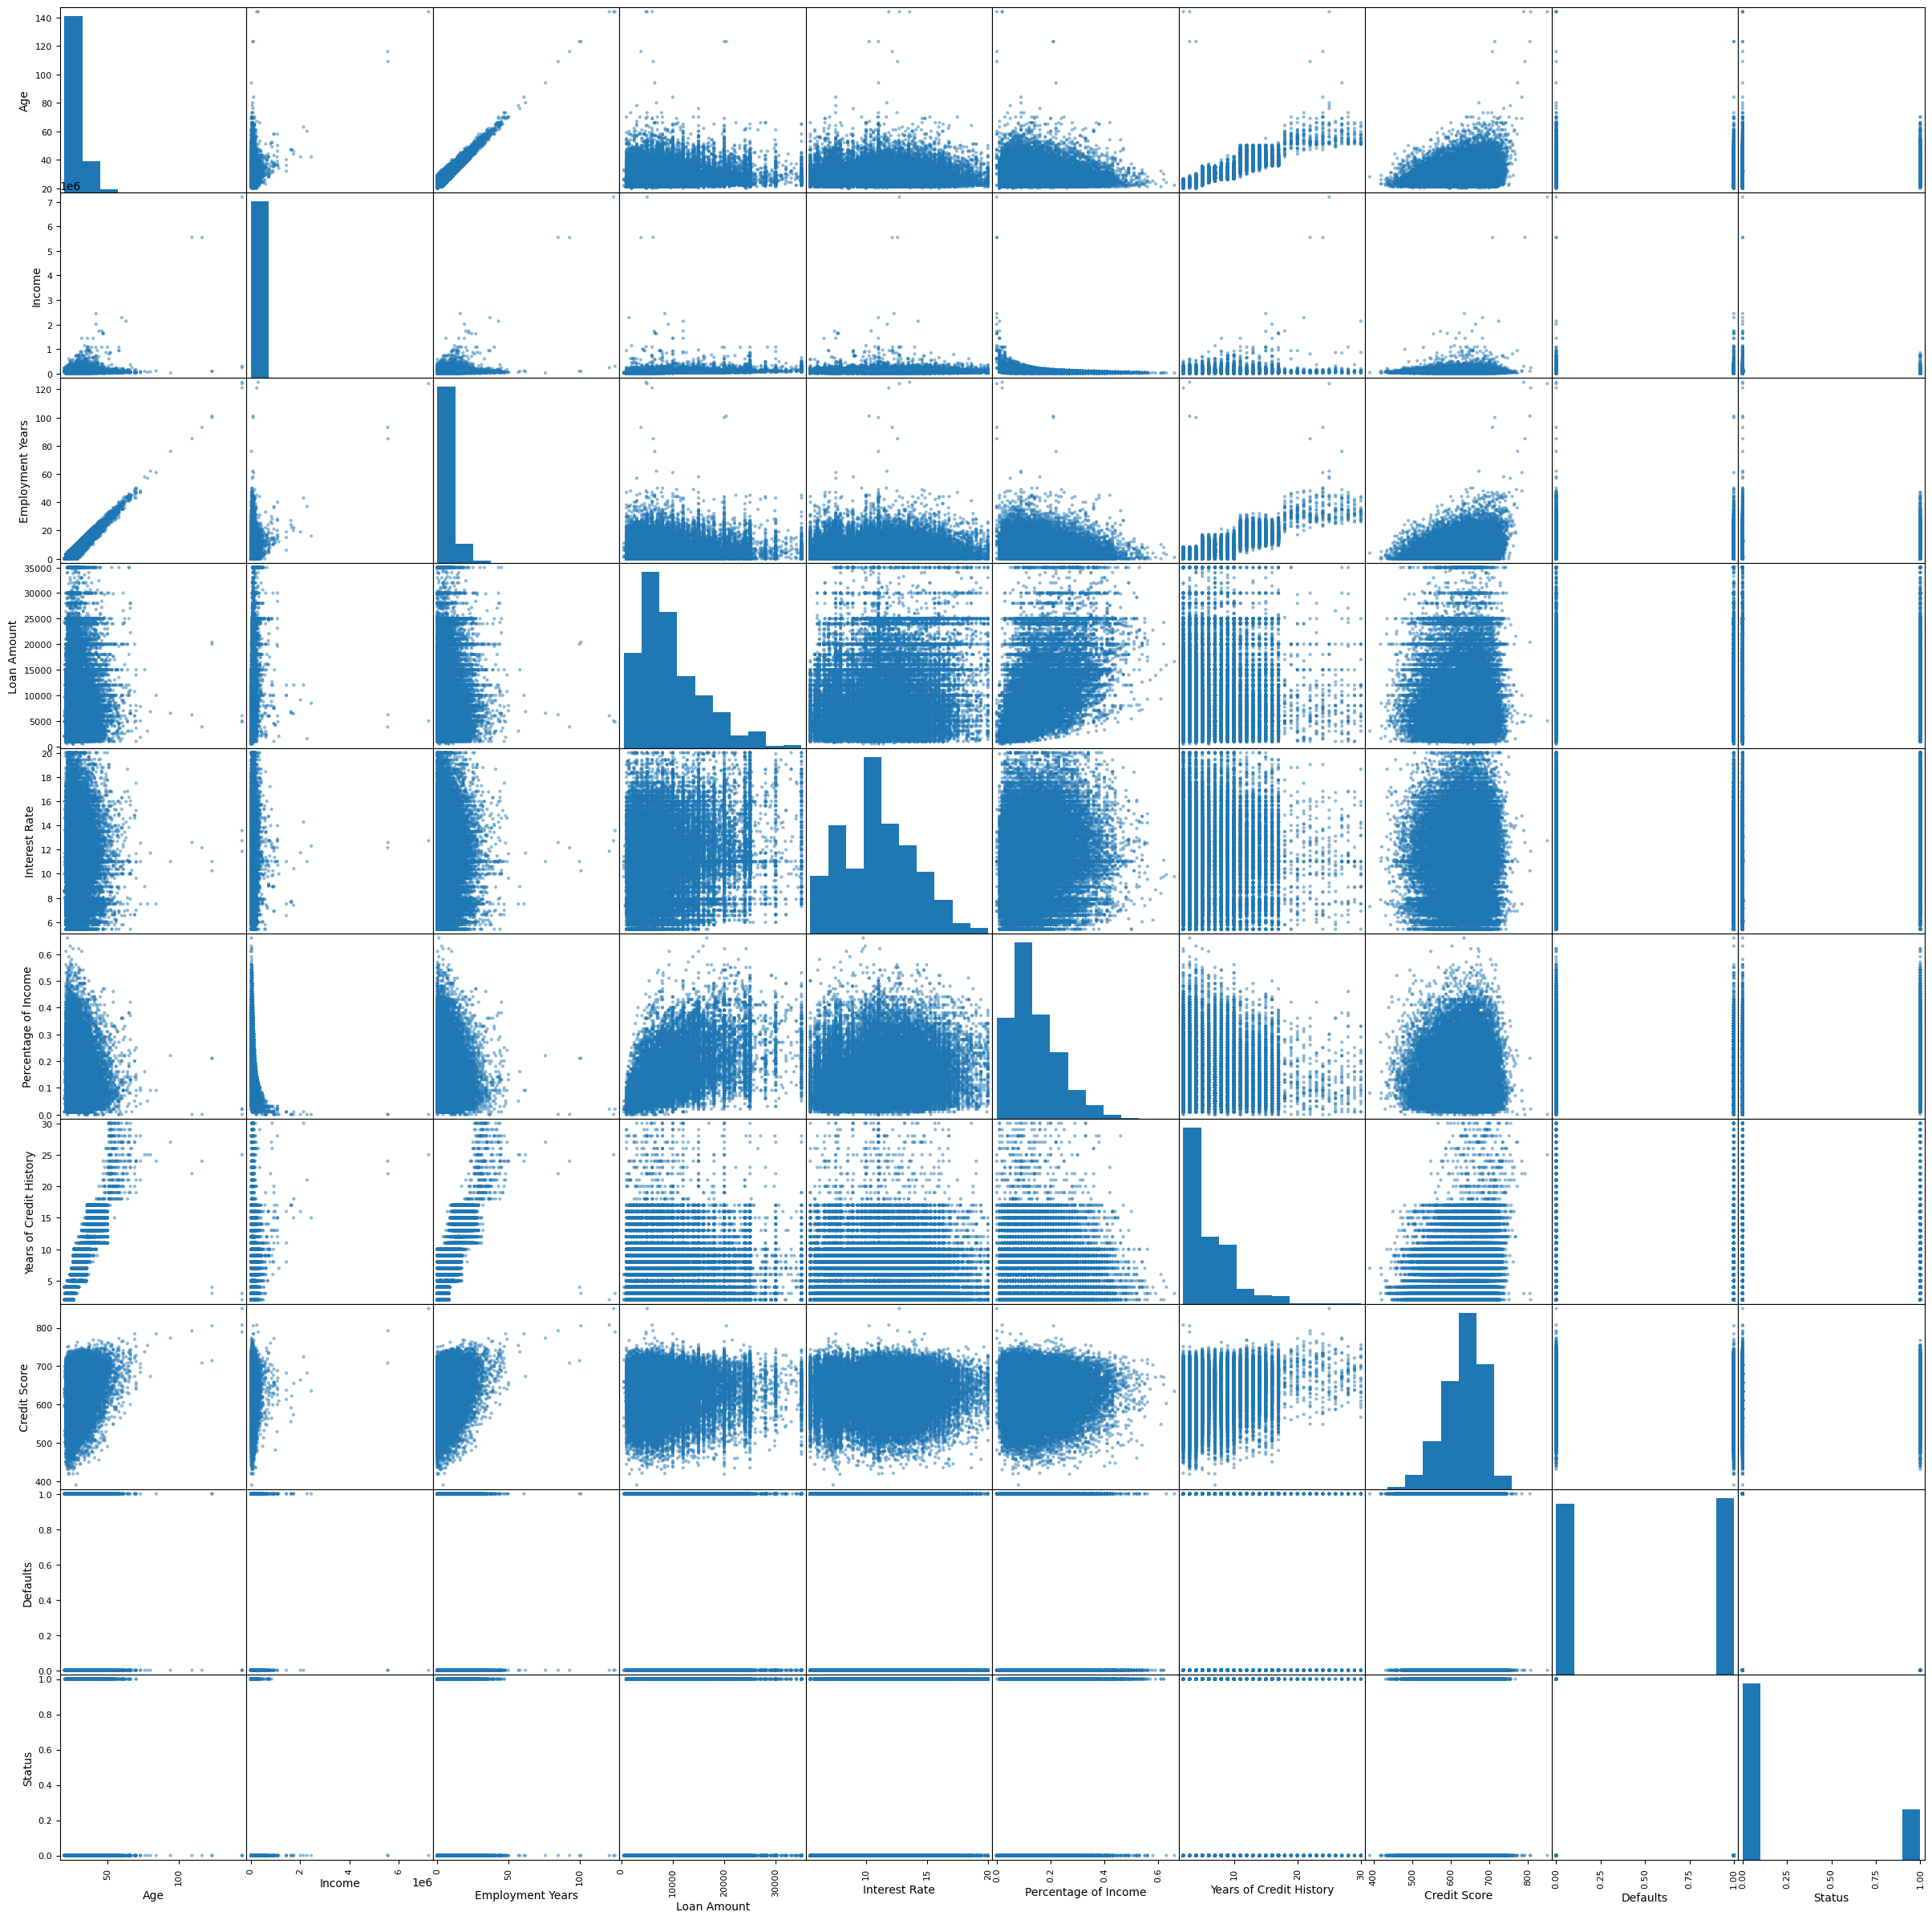

In [12]:
# create dataset with only numeric columns
numeric_df = df.select_dtypes(include = np.number)

fig, ax = plt.subplots(figsize = (30, 30))

scatter_matrix = pd.plotting.scatter_matrix(numeric_df, ax = ax, figsize = (12, 12), diagonal = 'hist')
plt.show

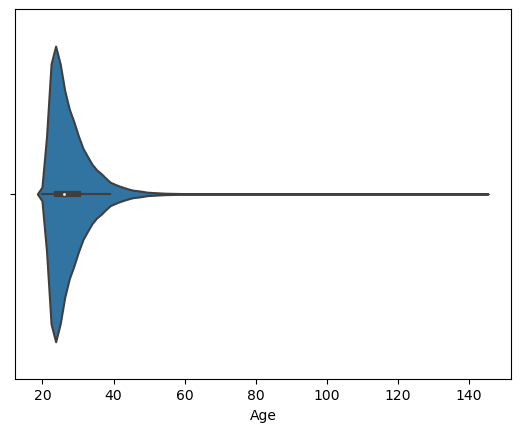

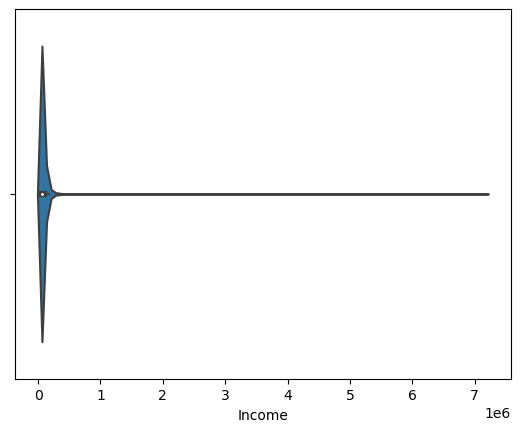

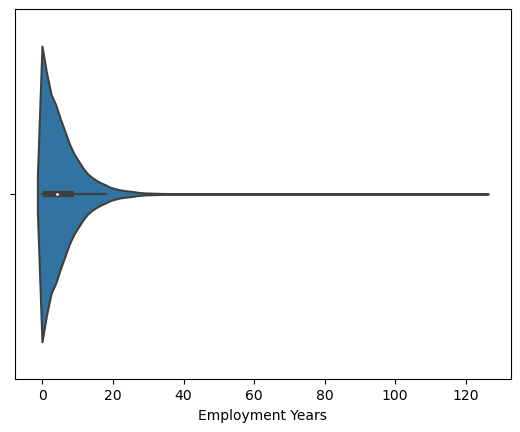

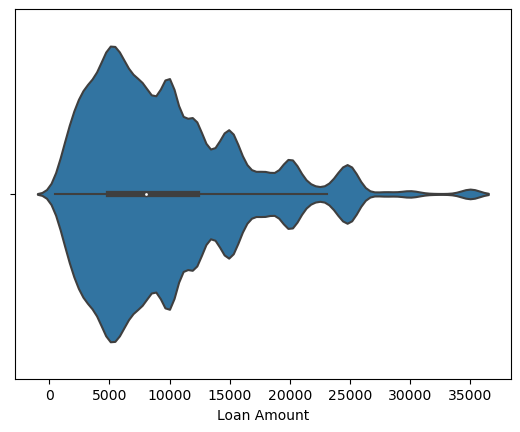

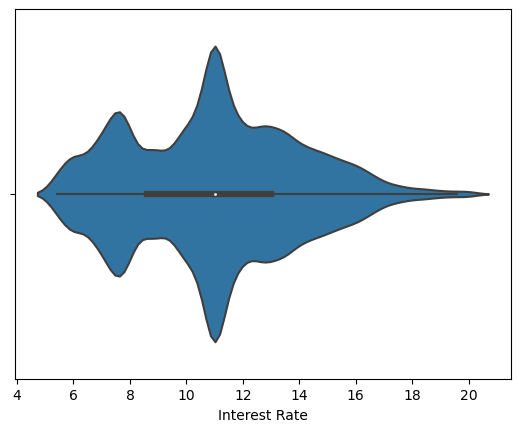

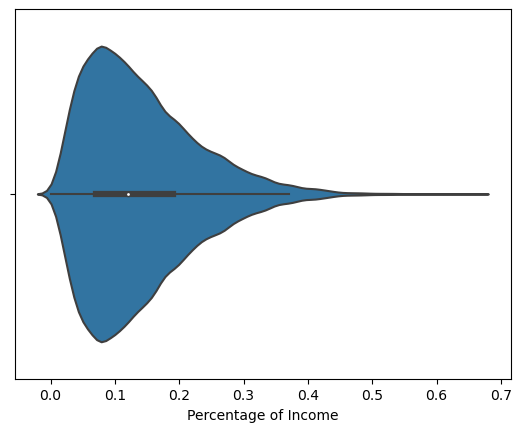

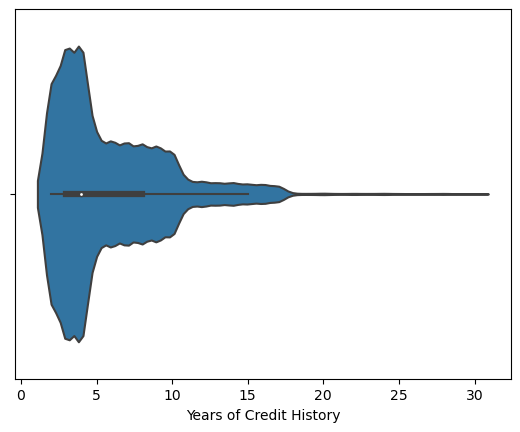

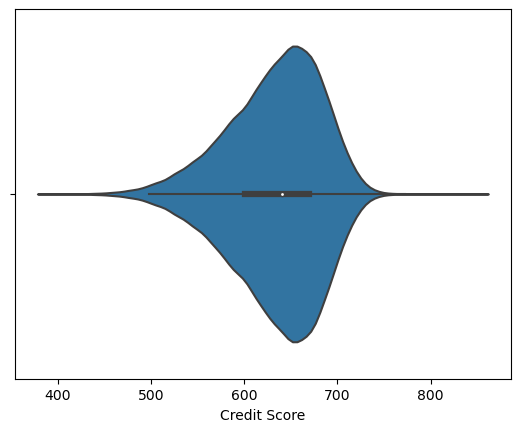

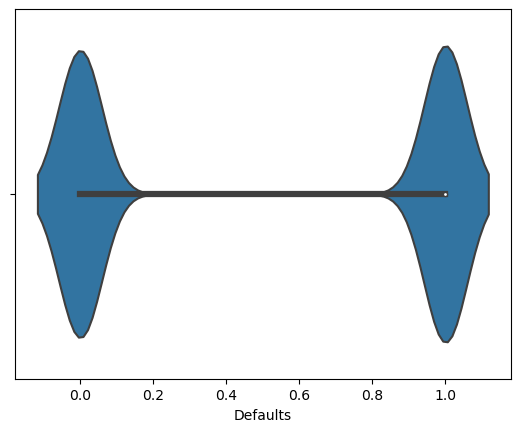

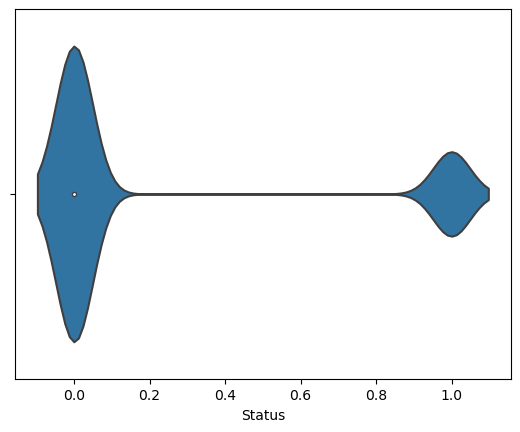

In [13]:
for col in numeric_df.columns:
    sns.violinplot(data = df, x = col)
    plt.show()

## 

## Examine Age

<Axes: >

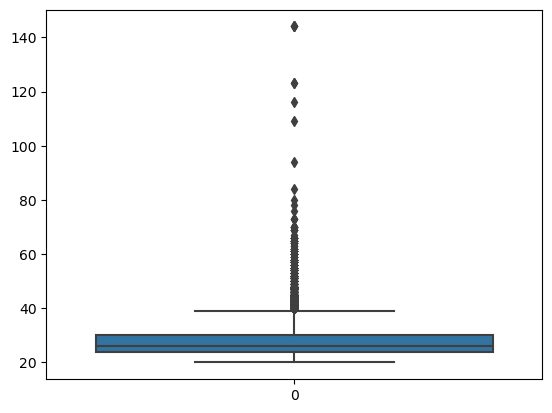

In [14]:
# examine perosn age
sns.boxplot(df['Age'])

In [15]:
over_100 = df[df['Age'] > 100]
print('Number of people over age 100:', len(over_100))
over_100

Number of people over age 100: 7


,Age,Sex,Education Level,Income,Employment Years,Home Ownership,Loan Amount,Loan Intent,Interest Rate,Percentage of Income,Years of Credit History,Credit Score,Defaults,Status
81,144.0,male,Bachelor,300616.0,125,RENT,4800.0,VENTURE,13.57,0.02,3.0,789,0,0
183,144.0,male,Associate,241424.0,121,MORTGAGE,6000.0,EDUCATION,11.86,0.02,2.0,807,0,0
575,123.0,female,High School,97140.0,101,RENT,20400.0,EDUCATION,10.25,0.21,3.0,805,1,0
747,123.0,male,Bachelor,94723.0,100,RENT,20000.0,VENTURE,11.01,0.21,4.0,714,1,0
32297,144.0,female,Associate,7200766.0,124,MORTGAGE,5000.0,PERSONAL,12.73,0.00,25.0,850,0,0
37930,116.0,male,Bachelor,5545545.0,93,MORTGAGE,3823.0,VENTURE,12.15,0.00,24.0,708,0,0
38113,109.0,male,High School,5556399.0,85,MORTGAGE,6195.0,VENTURE,12.58,0.00,22.0,792,0,0


In [16]:
# drop persons over the age of 100
df = df.drop(over_100.index, axis = 0)

In [17]:
age_sort = df.sort_values('Age', ascending = False)
age_sort.head()

,Age,Sex,Education Level,Income,Employment Years,Home Ownership,Loan Amount,Loan Intent,Interest Rate,Percentage of Income,Years of Credit History,Credit Score,Defaults,Status
32416,94.0,male,High School,29738.0,76,RENT,6500.0,MEDICAL,11.01,0.22,27.0,773,0,0
32506,84.0,male,High School,114705.0,61,MORTGAGE,10000.0,PERSONAL,7.51,0.09,24.0,784,1,0
32422,80.0,male,High School,77894.0,62,RENT,6800.0,MEDICAL,11.71,0.09,25.0,673,0,0
32355,78.0,male,Associate,58463.0,57,RENT,3000.0,MEDICAL,7.51,0.05,25.0,754,0,0
32534,76.0,female,Bachelor,90934.0,58,RENT,15000.0,MEDICAL,8.94,0.16,25.0,737,0,0


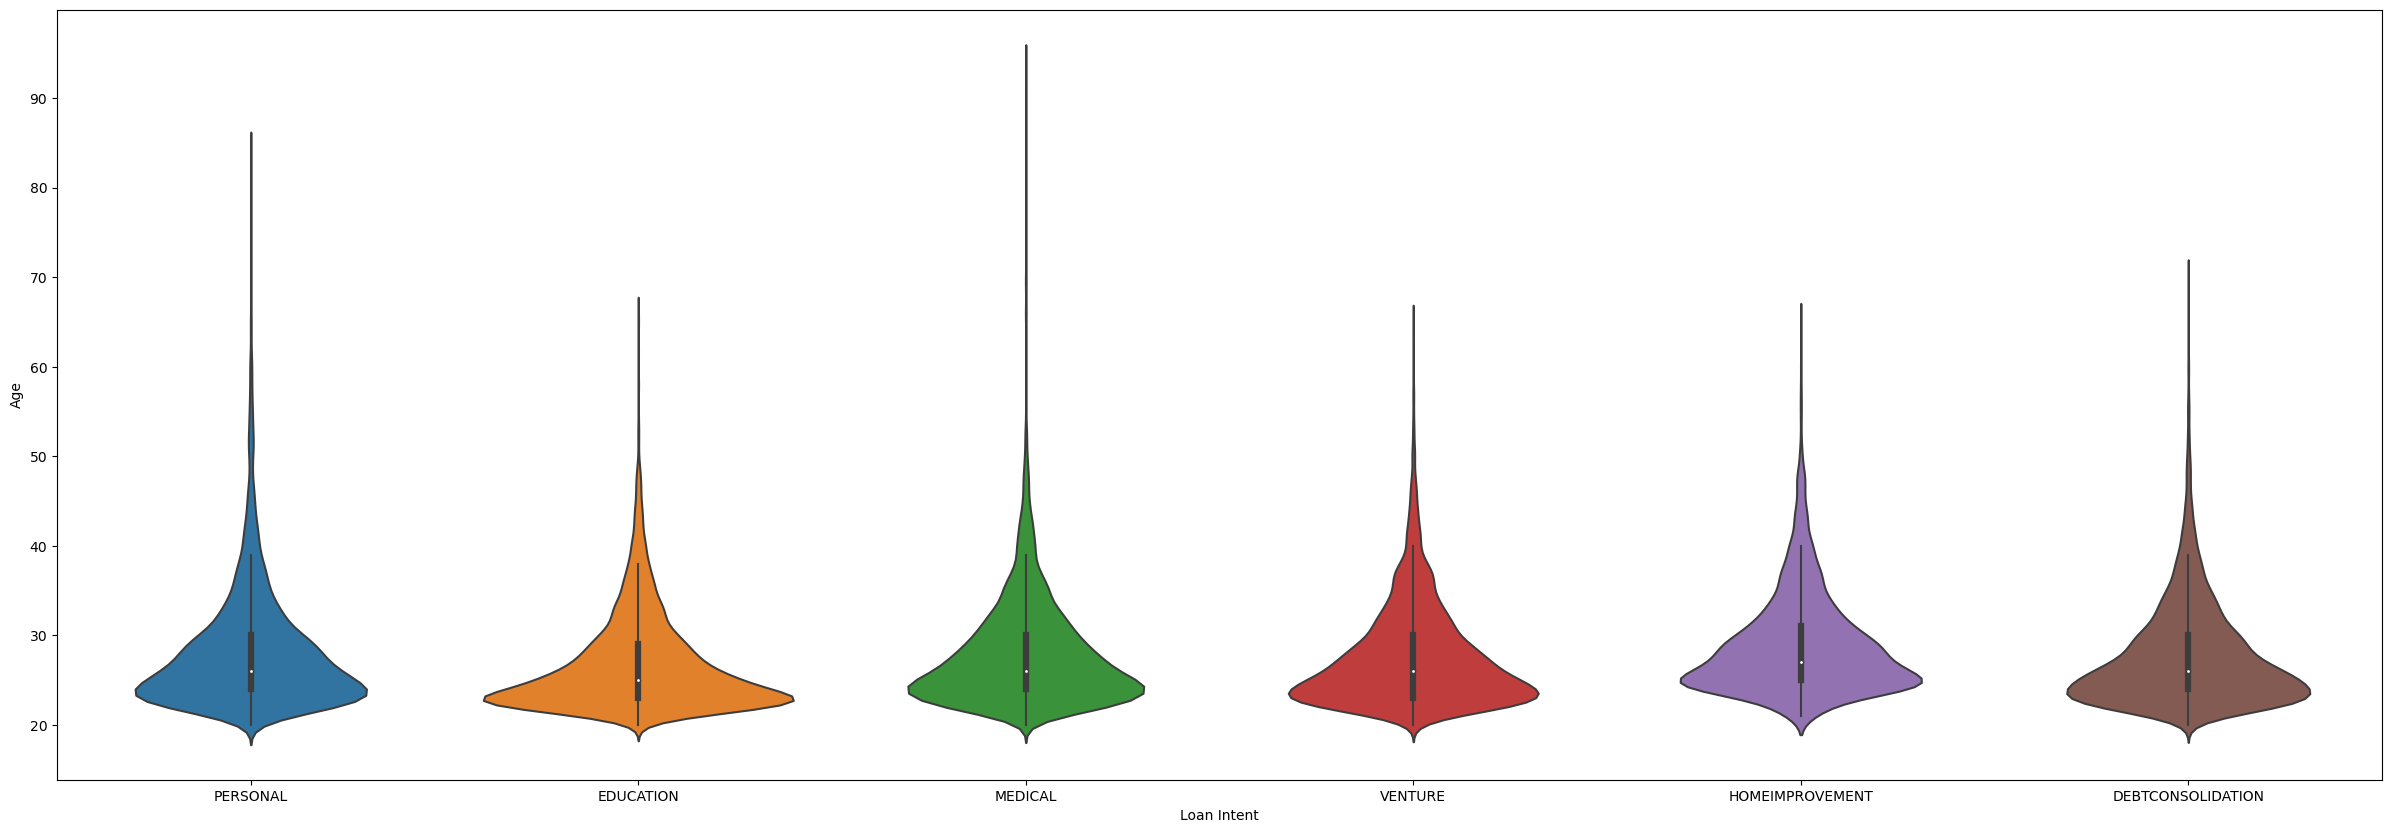

In [18]:
plt.figure(figsize=(30, 10))
sns.violinplot(data = df, x = 'Loan Intent', y = 'Age')
plt.show()

## Examine Person Income

<Axes: >

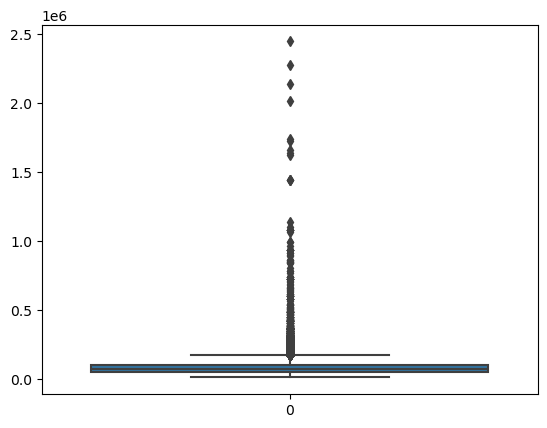

In [19]:
sns.boxplot(df['Income'])

In [20]:
income_sort = df.sort_values('Income', ascending = False)
income_sort.head(20)

,Age,Sex,Education Level,Income,Employment Years,Home Ownership,Loan Amount,Loan Intent,Interest Rate,Percentage of Income,Years of Credit History,Credit Score,Defaults,Status
30049,42.0,male,High School,2448661.0,16,RENT,8450.0,VENTURE,12.29,0.00,15.0,635,1,0
32546,60.0,female,High School,2280980.0,37,MORTGAGE,1500.0,PERSONAL,11.01,0.00,21.0,682,1,0
32497,63.0,male,High School,2139143.0,43,RENT,12025.0,EDUCATION,14.27,0.01,30.0,724,0,0
37175,42.0,male,High School,2012954.0,19,MORTGAGE,9121.0,VENTURE,11.74,0.00,16.0,664,0,0
41288,46.0,male,Associate,1741243.0,22,MORTGAGE,12011.0,VENTURE,10.42,0.01,18.0,655,1,0
31924,44.0,male,High School,1728974.0,20,MORTGAGE,6400.0,DEBTCONSOLIDATION,7.40,0.00,15.0,573,1,0
35850,47.0,male,Associate,1661567.0,22,MORTGAGE,6545.0,MEDICAL,7.65,0.00,17.0,622,1,0
31922,47.0,male,High School,1635757.0,24,MORTGAGE,6600.0,VENTURE,7.74,0.00,17.0,591,1,0
33132,47.0,male,Associate,1621992.0,27,MORTGAGE,6835.0,MEDICAL,7.66,0.00,17.0,555,1,0
29119,36.0,male,Doctorate,1440982.0,15,OWN,10000.0,MEDICAL,6.54,0.01,11.0,682,1,0


## Categorical Variables

In [21]:
categorical_df = df.select_dtypes(include = object)

Sex
female    20157
male      24836
Name: Status, dtype: int64 




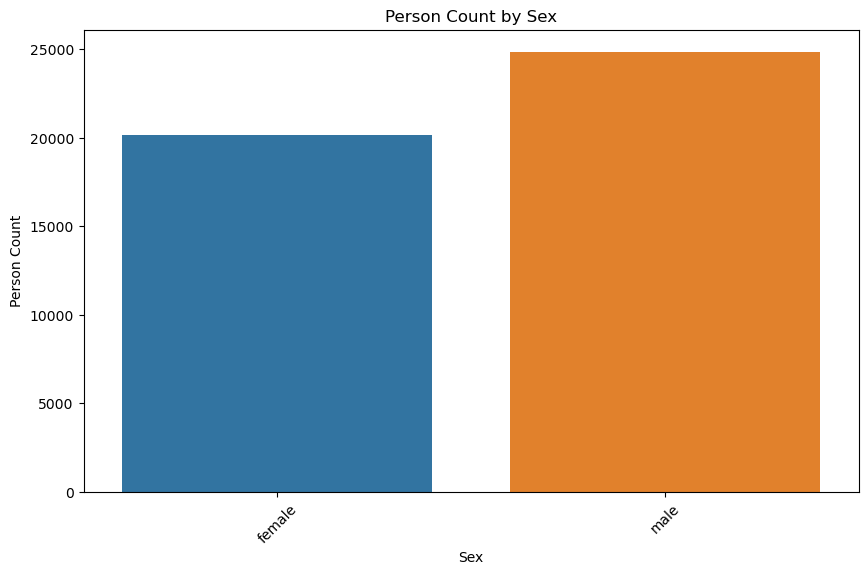

Education Level
Associate      12026
Bachelor       13396
Doctorate        621
High School    11970
Master          6980
Name: Status, dtype: int64 




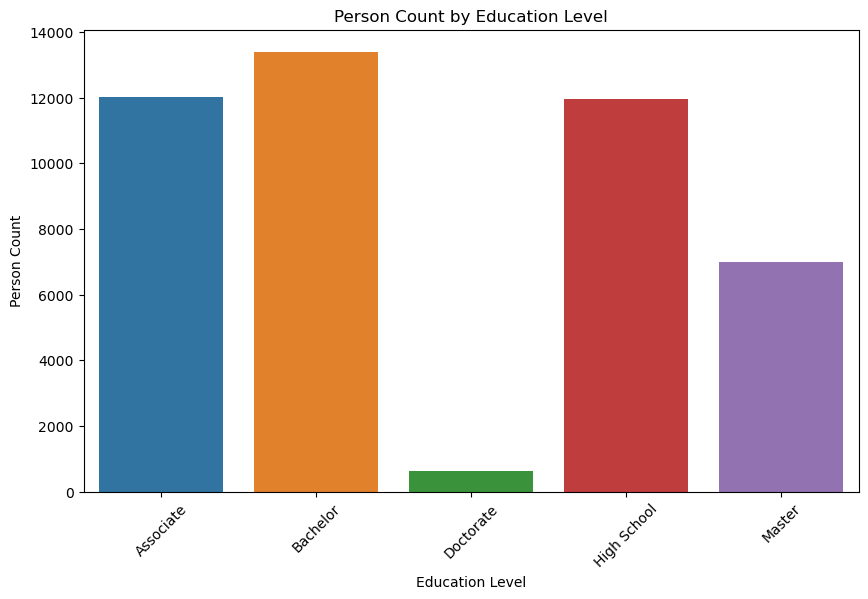

Home Ownership
MORTGAGE    18485
OTHER         117
OWN          2951
RENT        23440
Name: Status, dtype: int64 




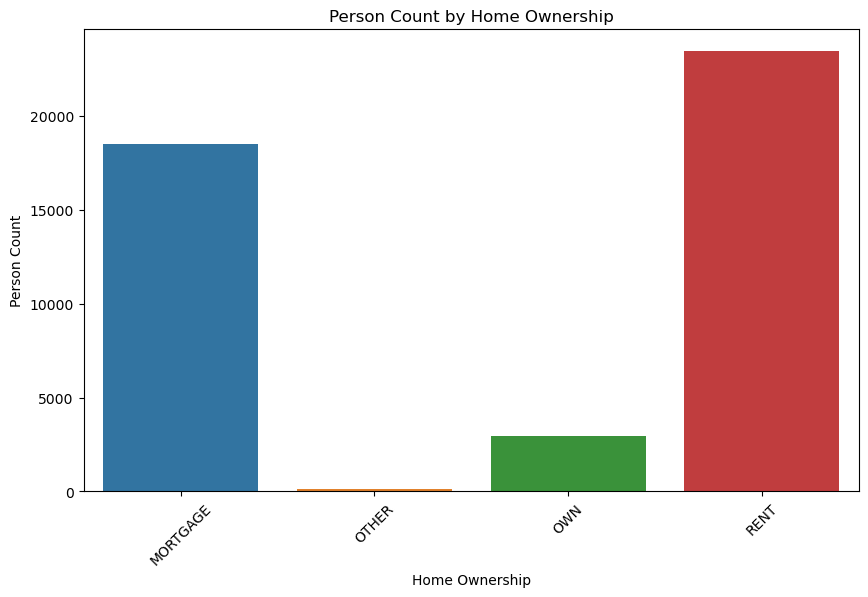

Loan Intent
DEBTCONSOLIDATION    7145
EDUCATION            9151
HOMEIMPROVEMENT      4783
MEDICAL              8548
PERSONAL             7551
VENTURE              7815
Name: Status, dtype: int64 




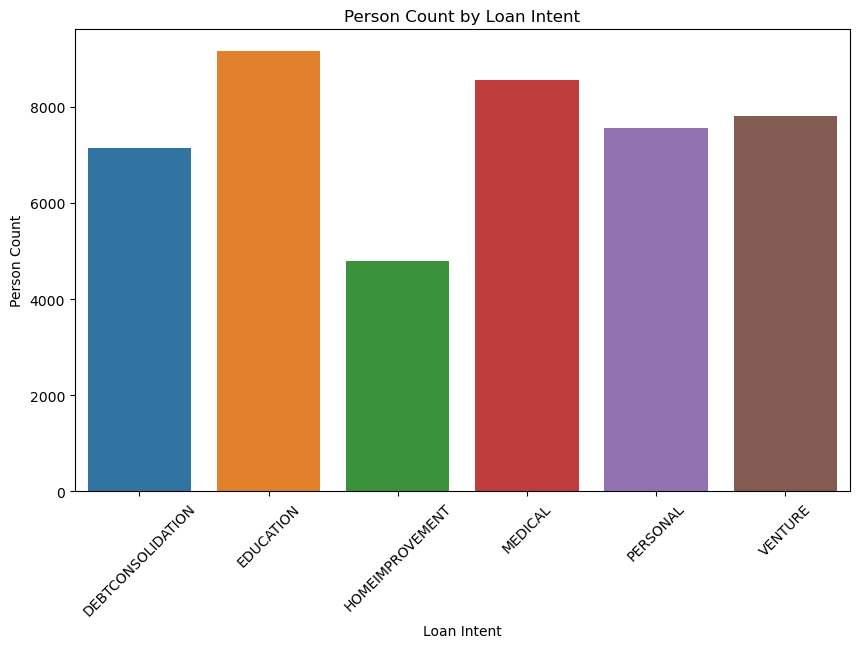

In [22]:
for col in categorical_df.columns:
    temp = df.groupby(col)['Status'].count()
    print(temp, '\n\n')

    # Plot the counts as a bar chart
    plt.figure(figsize = (10, 6))
    sns.barplot(x = temp.index, y = temp.values)
    plt.title(f'Person Count by {col}')
    plt.xlabel(col)
    plt.ylabel('Person Count')
    plt.xticks(rotation = 45)  # Rotate x-axis labels if needed for readability
    plt.show()

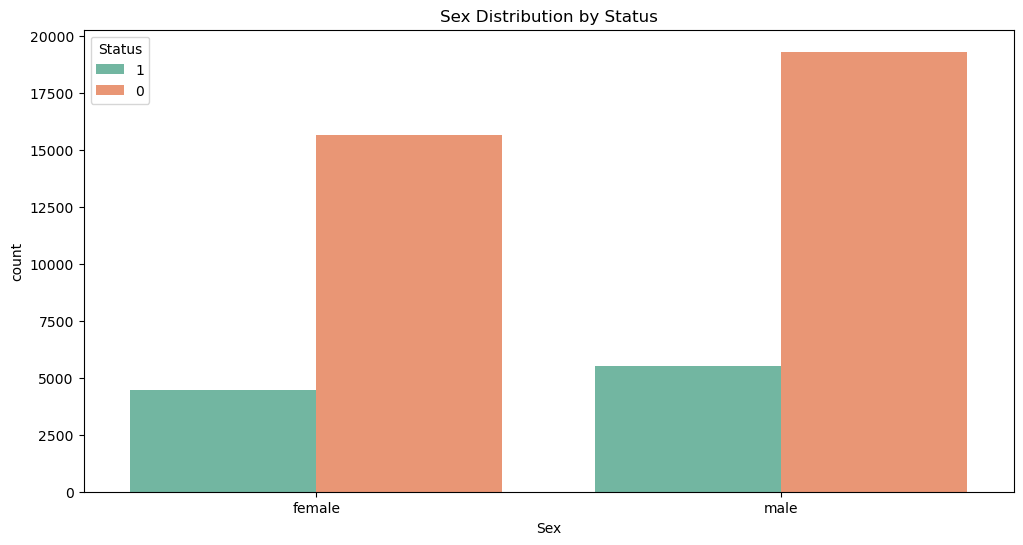

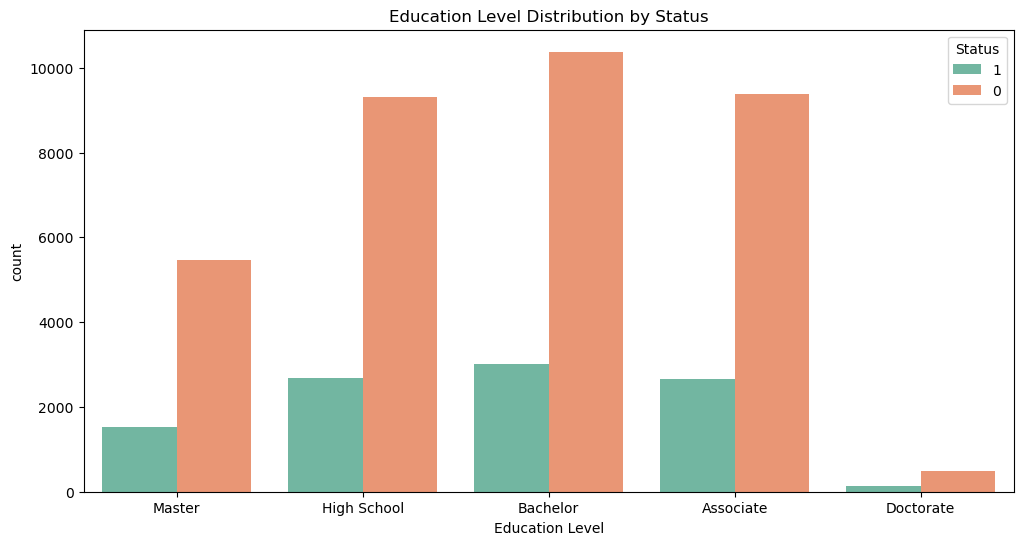

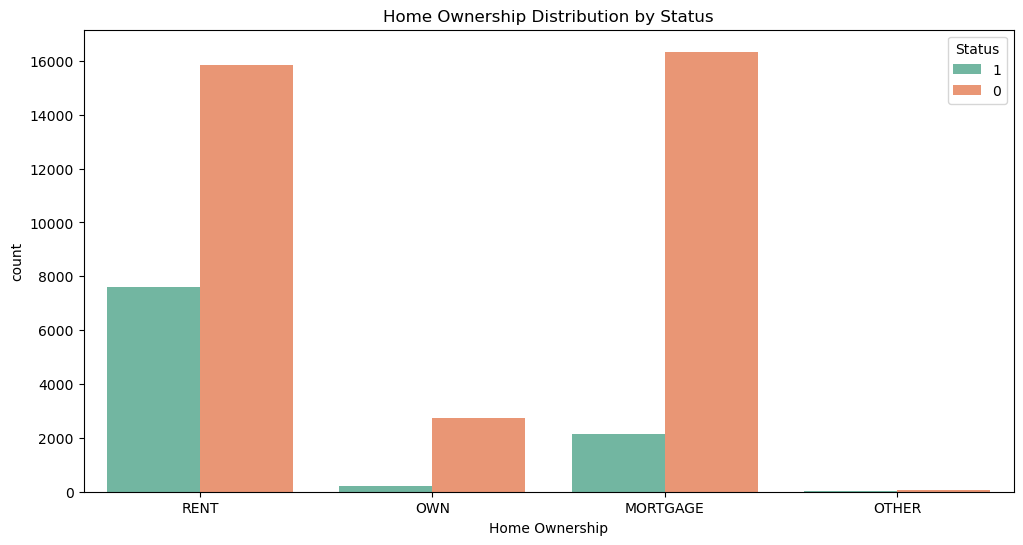

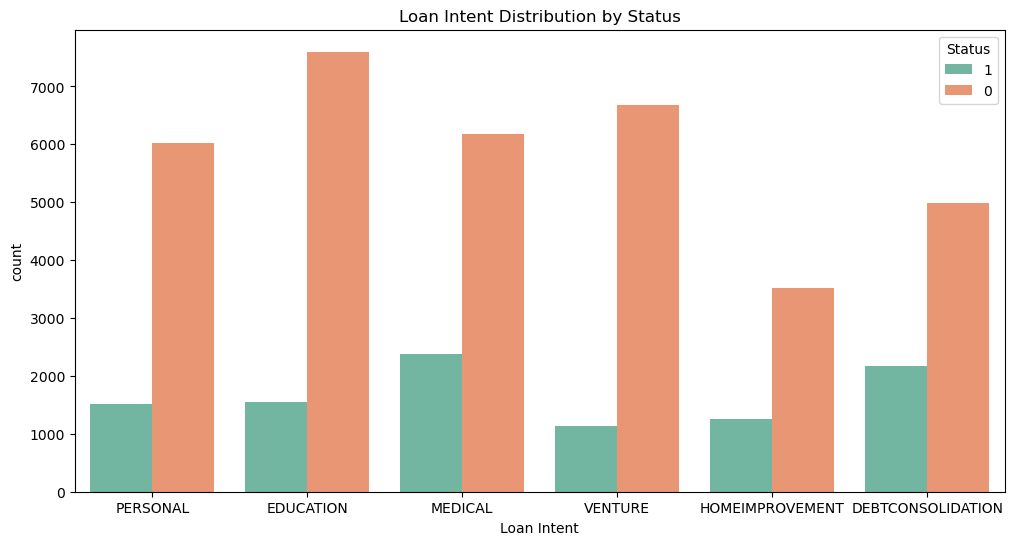

In [23]:
# temporarily convert status to string
df['Status'] = df['Status'].astype('str')

for col in categorical_df.columns:
    plt.figure(figsize=(12, 6))
    sns.countplot(data = df, x = col, hue = 'Status', palette = 'Set2')
    plt.title(f'{col} Distribution by Status')
    plt.show()

Home Ownership
MORTGAGE    633.002975
OTHER       627.803419
OWN         632.058285
RENT        632.346928
Name: Credit Score, dtype: float64 




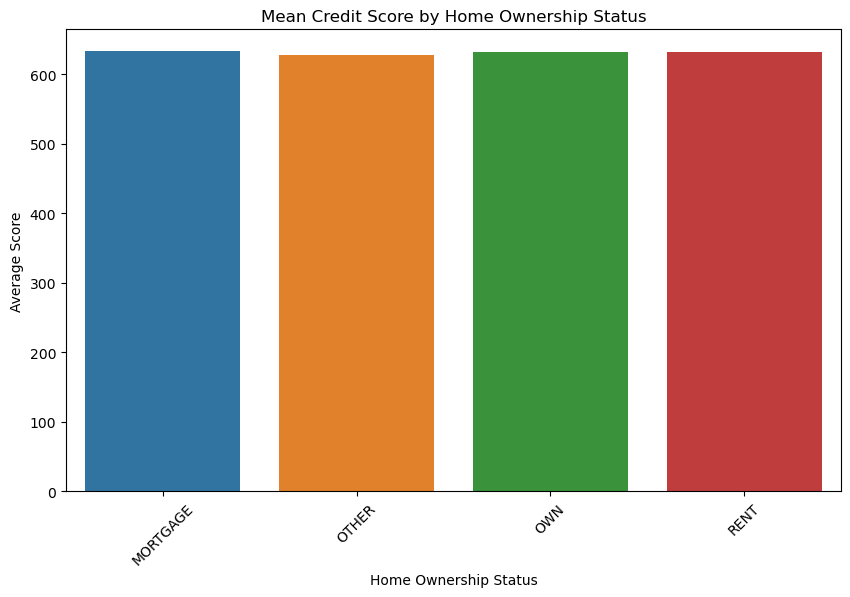

In [24]:
temp = df.groupby('Home Ownership')['Credit Score'].mean()
print(temp, '\n\n')

plt.figure(figsize = (10, 6))
sns.barplot(x = temp.index, y = temp.values)
plt.title(f'Mean Credit Score by Home Ownership Status')
plt.xlabel('Home Ownership Status')
plt.ylabel('Average Score')
plt.xticks(rotation = 45)  # Rotate x-axis labels if needed for readability
plt.show()

In [25]:
# convert status back to int
df['Status'] = df['Status'].astype('category').cat.codes

## Investigate Statistical Significance of Categorical Variables

In [26]:
from sklearn.preprocessing import LabelEncoder
from scipy.stats import chi2_contingency

In [27]:
# make a duplicate dataset of categorical features where features have been one-hot encoded
dummies_df = pd.get_dummies(categorical_df)

In [28]:
for col in dummies_df.columns:
    # contingency table
    contingency_table = pd.crosstab(dummies_df[col], df['Status'])
    print(f'Contingency table for {col}:\n{contingency_table}\n')
    # chi-square test
    chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)
    print(f'Chi-square test results for {col}:\n\tChi-square statistic: {chi2_stat: .2f}\n\tP-value: {p_value:.4f}\n\tDegrees of Freedom: {dof}\n\tExpected Frequencies:\n{expected}\n')
    if p_value > .05:
        print(f'No significant association between {col} and Status\n')
    else:
        print(f'There is a statistically significant relationship between {col} and Status\n')
    print('-----------------------------------------------------------------')

Contingency table for Sex_female:
Status          0     1
Sex_female             
False       19321  5515
True        15672  4485

Chi-square test results for Sex_female:
	Chi-square statistic:  0.01
	P-value: 0.9188
	Degrees of Freedom: 1
	Expected Frequencies:
[[19316.03022692  5519.96977308]
 [15676.96977308  4480.03022692]]

No significant association between Sex_female and Status

-----------------------------------------------------------------
Contingency table for Sex_male:
Status        0     1
Sex_male             
False     15672  4485
True      19321  5515

Chi-square test results for Sex_male:
	Chi-square statistic:  0.01
	P-value: 0.9188
	Degrees of Freedom: 1
	Expected Frequencies:
[[15676.96977308  4480.03022692]
 [19316.03022692  5519.96977308]]

No significant association between Sex_male and Status

-----------------------------------------------------------------
Contingency table for Education Level_Associate:
Status                         0     1
Education Level_

#### Results:
* Sex is not a relevant feature
* Education level is not a relevant feature
* Home Ownership is a relevant feature
* Loan Intent is a relevant feature

## Correlation

In [29]:
# correlation matrix for numeric features
corr = numeric_df.corr()
corr

,Age,Income,Employment Years,Loan Amount,Interest Rate,Percentage of Income,Years of Credit History,Credit Score,Defaults,Status
Age,1.000000,0.193698,0.954412,0.050750,0.013402,-0.043299,0.861985,0.178432,-0.025917,-0.021476
Income,0.193698,1.000000,0.185987,0.242290,0.001510,-0.234177,0.124316,0.035919,0.061483,-0.135808
Employment Years,0.954412,0.185987,1.000000,0.044589,0.016631,-0.039862,0.824272,0.186196,-0.029231,-0.020481
Loan Amount,0.050750,0.242290,0.044589,1.000000,0.146093,0.593011,0.042969,0.009074,-0.059009,0.107714
Interest Rate,0.013402,0.001510,0.016631,0.146093,1.000000,0.125209,0.018008,0.011498,-0.181800,0.332005
Percentage of Income,-0.043299,-0.234177,-0.039862,0.593011,0.125209,1.000000,-0.031868,-0.011483,-0.203252,0.384880
Years of Credit History,0.861985,0.124316,0.824272,0.042969,0.018008,-0.031868,1.000000,0.155204,-0.022640,-0.014851
Credit Score,0.178432,0.035919,0.186196,0.009074,0.011498,-0.011483,0.155204,1.000000,-0.183005,-0.007647
Defaults,-0.025917,0.061483,-0.029231,-0.059009,-0.181800,-0.203252,-0.022640,-0.183005,1.000000,-0.543096
Status,-0.021476,-0.135808,-0.020481,0.107714,0.332005,0.384880,-0.014851,-0.007647,-0.543096,1.000000


<Axes: >

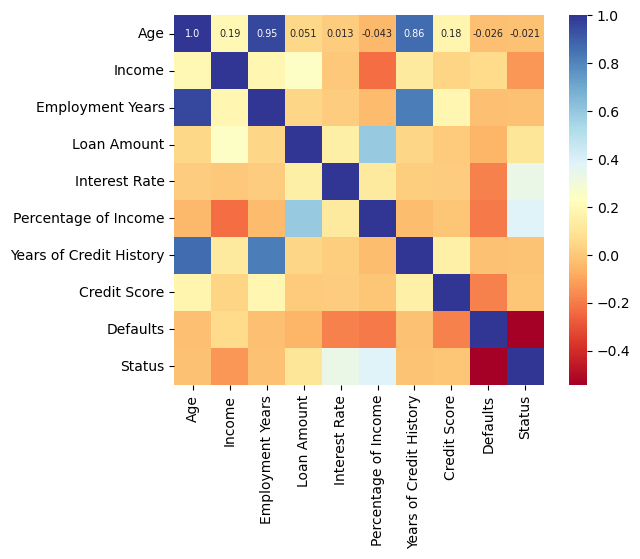

In [30]:
sns.heatmap(corr, annot = True, fmt = '.2', cmap = 'RdYlBu', annot_kws={'size': 7}, square = True)

In [31]:
# correlation matrix for relevant categorical variables
dummies_cols = ['Home Ownership_RENT', 'Home Ownership_OTHER', 'Home Ownership_MORTGAGE', 
                'Home Ownership_OWN', 'Loan Intent_DEBTCONSOLIDATION', 'Loan Intent_EDUCATION',
                'Loan Intent_HOMEIMPROVEMENT', 'Loan Intent_MEDICAL', 'Loan Intent_PERSONAL',
                'Loan Intent_VENTURE']
cat_corr_df = pd.concat([df['Status'], dummies_df[dummies_cols]], axis = 1)

cat_corr = cat_corr_df.corr()
cat_corr

,Status,Home Ownership_RENT,Home Ownership_OTHER,Home Ownership_MORTGAGE,Home Ownership_OWN,Loan Intent_DEBTCONSOLIDATION,Loan Intent_EDUCATION,Loan Intent_HOMEIMPROVEMENT,Loan Intent_MEDICAL,Loan Intent_PERSONAL,Loan Intent_VENTURE
Status,1.000000,0.255249,0.013642,-0.213447,-0.093691,0.084097,-0.063996,0.033810,0.065158,-0.022495,-0.085925
Home Ownership_RENT,0.255249,1.000000,-0.053249,-0.870856,-0.276292,0.031122,0.002498,-0.054966,0.061668,-0.014387,-0.037624
Home Ownership_OTHER,0.013642,-0.053249,1.000000,-0.042639,-0.013528,-0.001886,-0.006284,-0.000620,-0.001366,0.002761,0.007693
Home Ownership_MORTGAGE,-0.213447,-0.870856,-0.042639,1.000000,-0.221240,0.016011,-0.003436,0.050703,-0.054340,0.011814,-0.008434
Home Ownership_OWN,-0.093691,-0.276292,-0.013528,-0.221240,1.000000,-0.094233,0.003079,0.010280,-0.016168,0.004984,0.091102
Loan Intent_DEBTCONSOLIDATION,0.084097,0.031122,-0.001886,0.016011,-0.094233,1.000000,-0.219542,-0.149852,-0.210423,-0.195120,-0.199205
Loan Intent_EDUCATION,-0.063996,0.002498,-0.006284,-0.003436,0.003079,-0.219542,1.000000,-0.174269,-0.244710,-0.226914,-0.231665
Loan Intent_HOMEIMPROVEMENT,0.033810,-0.054966,-0.000620,0.050703,0.010280,-0.149852,-0.174269,1.000000,-0.167031,-0.154884,-0.158126
Loan Intent_MEDICAL,0.065158,0.061668,-0.001366,-0.054340,-0.016168,-0.210423,-0.244710,-0.167031,1.000000,-0.217488,-0.222042
Loan Intent_PERSONAL,-0.022495,-0.014387,0.002761,0.011814,0.004984,-0.195120,-0.226914,-0.154884,-0.217488,1.000000,-0.205894


<Axes: >

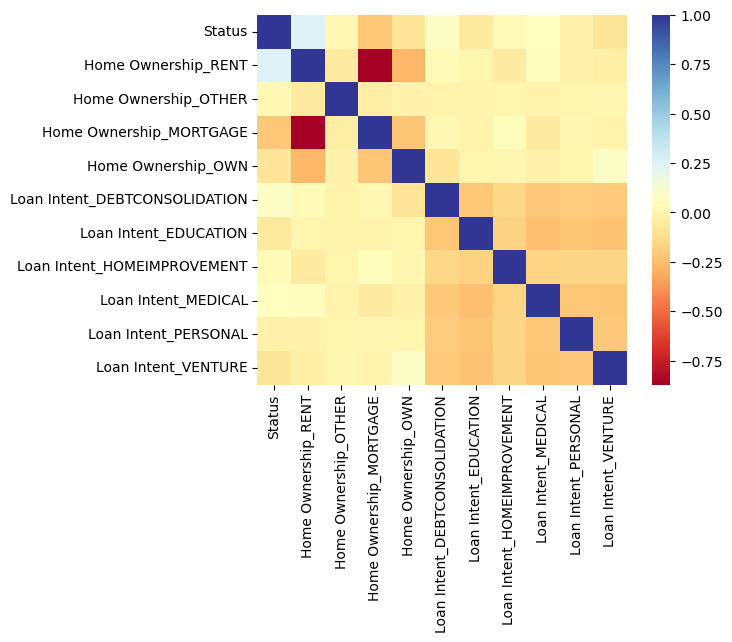

In [32]:
sns.heatmap(cat_corr,  fmt = '.2', cmap = 'RdYlBu', annot_kws={'size': 7}, square = True)

#### Results:
__Highly Correlated Numeric Features__
* Income
* Interest Rate
* Percentage of Income
* Defaults

__Highly Correlated Categorical Features__
* Home Ownership: Rent
* Home Ownership: Mortgage  
(These are highly correlated with one another)
* Loan Intent: Venture

# Preprocessing

In [33]:
df.describe()

,Age,Income,Employment Years,Loan Amount,Interest Rate,Percentage of Income,Years of Credit History,Credit Score,Defaults,Status
count,44993.000000,4.499300e+04,44993.000000,44993.000000,44993.000000,44993.000000,44993.000000,44993.000000,44993.000000,44993.000000
mean,27.748428,7.990845e+04,5.394528,9583.176761,11.006448,0.139736,5.866557,632.585713,0.507990,0.222257
std,5.909737,6.332213e+04,5.927159,6314.802655,2.978985,0.087207,3.877167,50.402411,0.499942,0.415767
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000,0.000000
25%,24.000000,4.719500e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000,0.000000
50%,26.000000,6.704600e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,1.000000,0.000000
75%,30.000000,9.577800e+04,8.000000,12237.000000,12.990000,0.190000,8.000000,670.000000,1.000000,0.000000
max,94.000000,2.448661e+06,76.000000,35000.000000,20.000000,0.660000,30.000000,784.000000,1.000000,1.000000


## Split Data

In [34]:
# split data into training and test set
from sklearn.model_selection import train_test_split

X = df.drop(['Status'], axis = 1)
y = df['Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 11)

In [35]:
# split into validation set
X = X_train
y = y_train

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, random_state = 11)

In [36]:
print(f'Training set size: {len(X_train)}')
print(f'Validation set size: {len(X_val)}')
print(f'Testing set size: {len(X_test)}')

Training set size: 28795
Validation set size: 7199
Testing set size: 8999


## Determine Standardizing methods

## Plot Histograms

C:\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


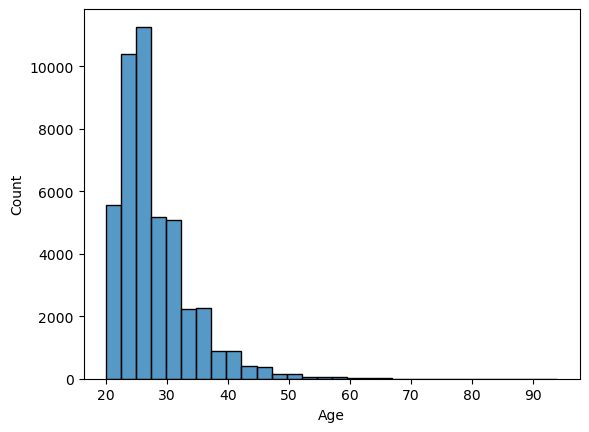

C:\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


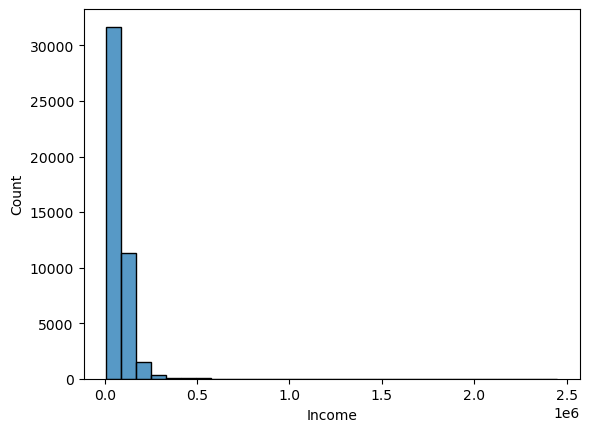

C:\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


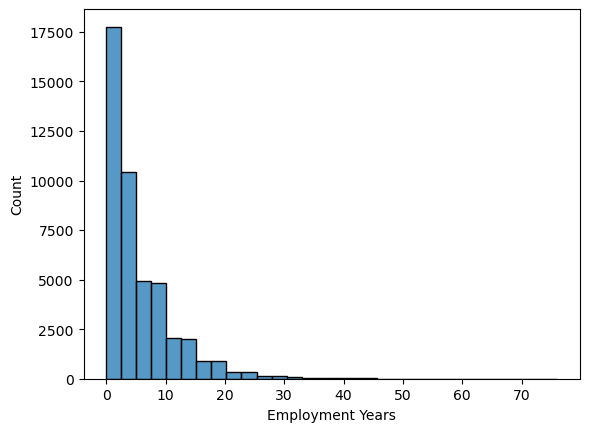

C:\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


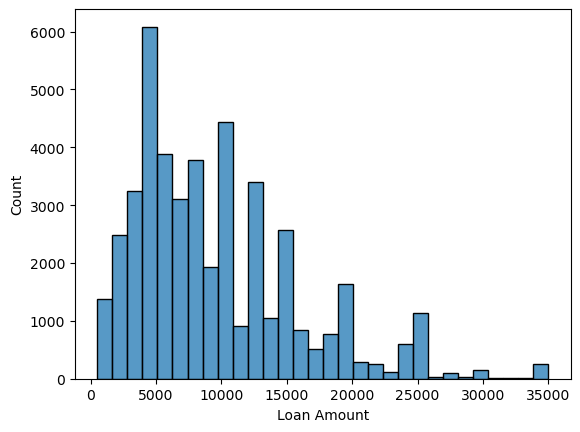

C:\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


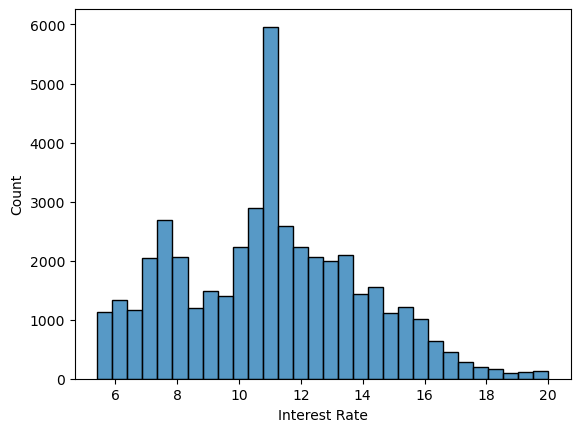

C:\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


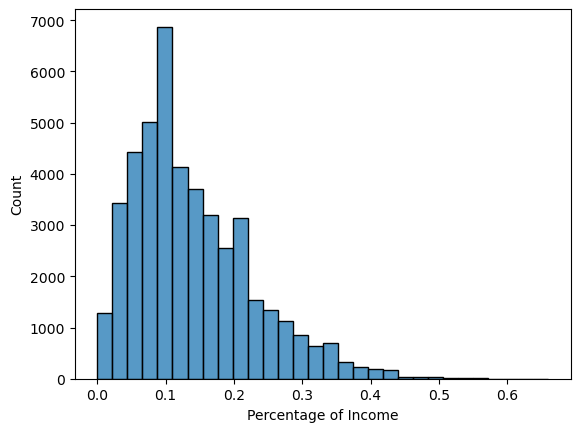

C:\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


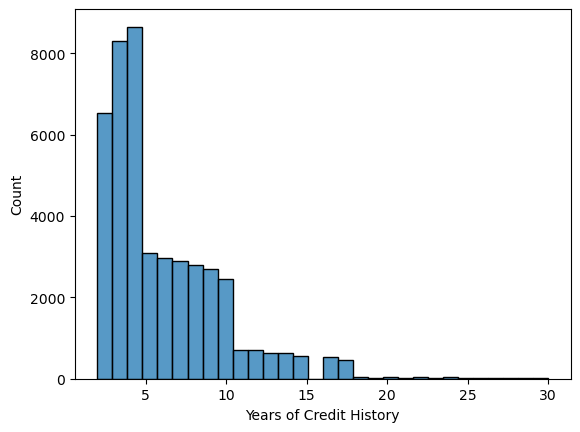

C:\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


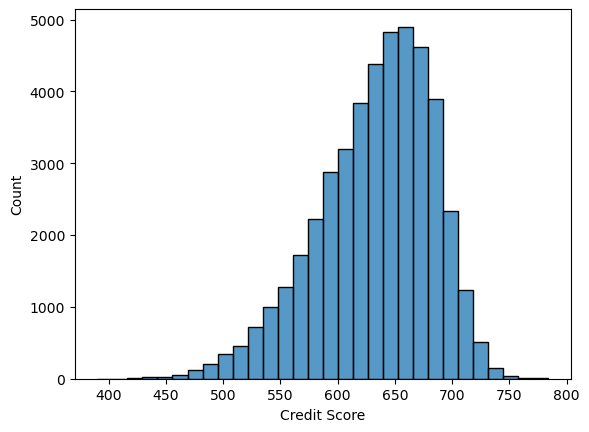

C:\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


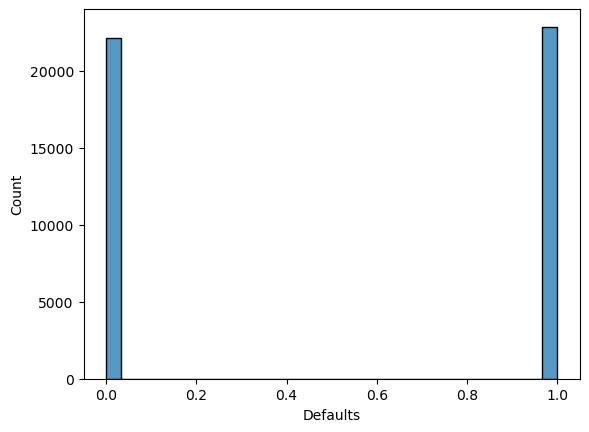

C:\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


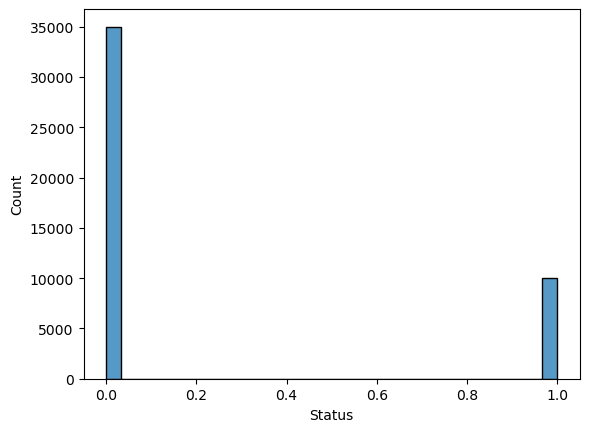

In [37]:
for col in numeric_df.columns:
    sns.histplot(data = df, x = col, bins = 30)
    plt.show()

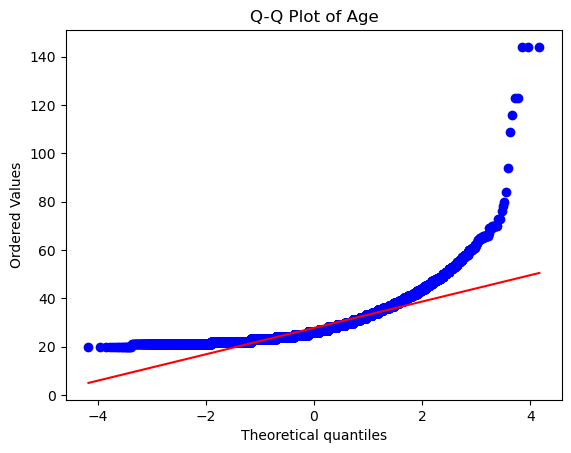

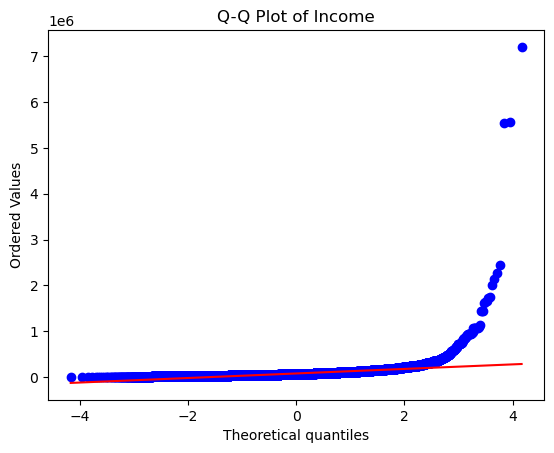

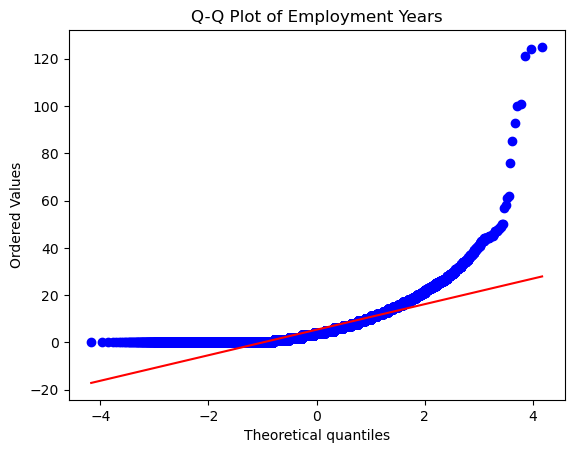

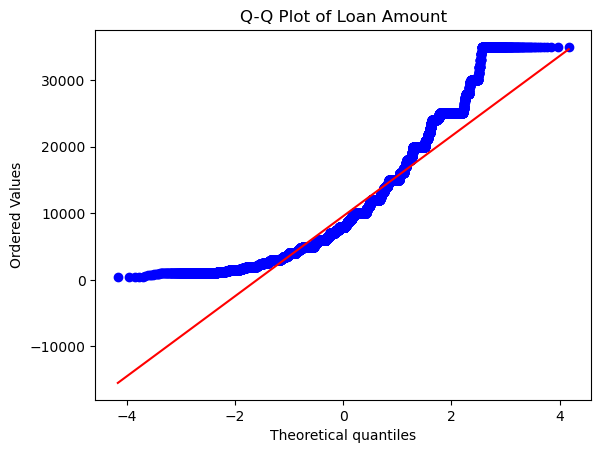

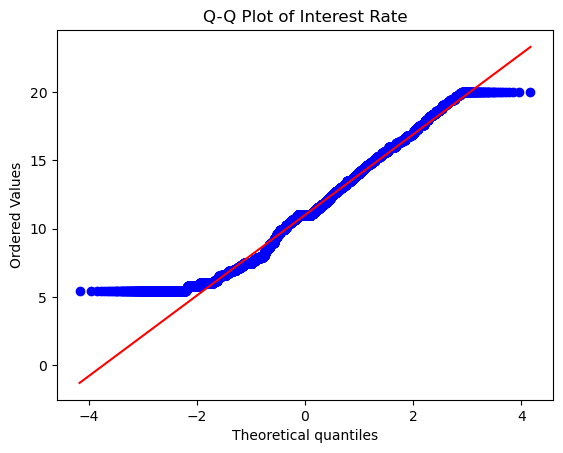

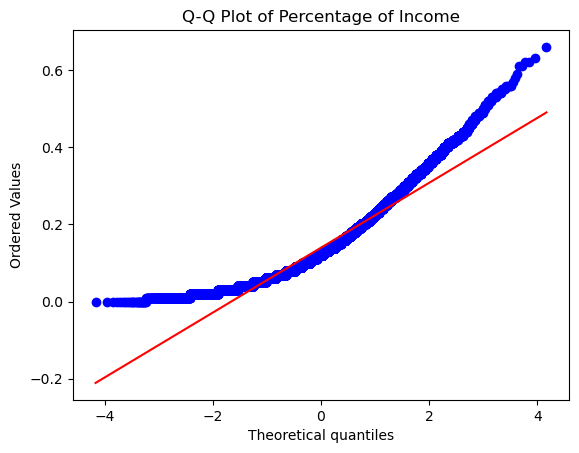

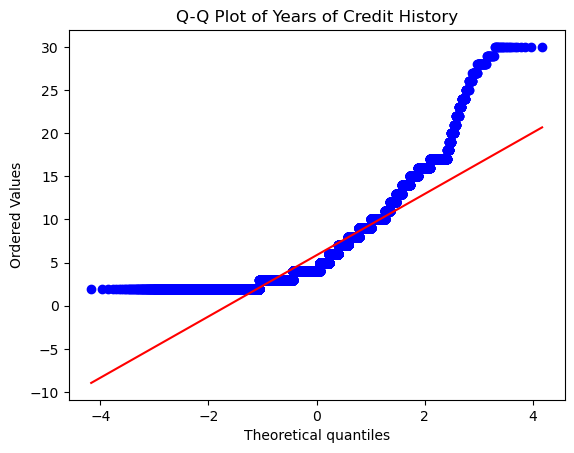

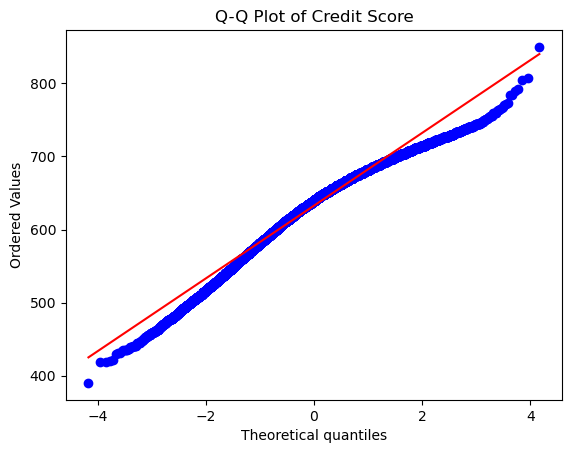

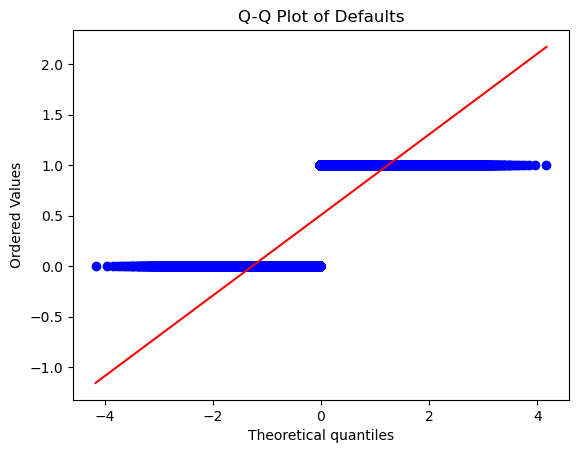

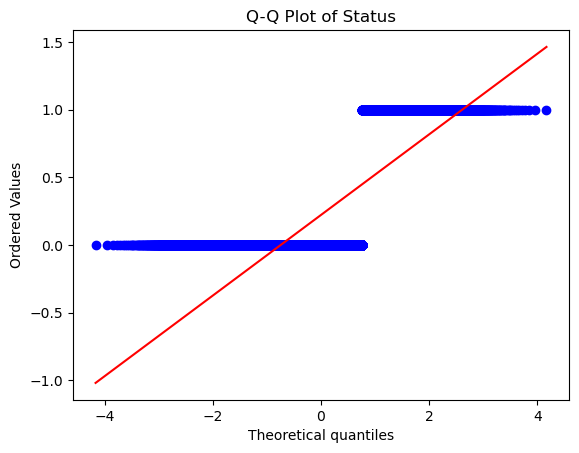

In [38]:
# first investigate distribution of features
# credit score is definitely gaussian
# age, income, employment years are definitely pareto
# investigate the remaining numeric features
import scipy.stats as stats
# create Q-Q plots
# plots that closely follow red line indicate gaussian distribution
for col in numeric_df.columns:
    stats.probplot(numeric_df[col], dist = "norm", plot = plt)
    plt.title(f"Q-Q Plot of {col}")
    plt.show()

In [39]:
# Examine skew values
# gaussian distributions will have a value close to 0
print(numeric_df.skew())

Age                         2.548154
Income                     34.137583
Employment Years            2.594917
Loan Amount                 1.179731
Interest Rate               0.213784
Percentage of Income        1.034512
Years of Credit History     1.631720
Credit Score               -0.610261
Defaults                   -0.031827
Status                      1.336351
dtype: float64


In [40]:
# Examine kurtosis values
# gaussian distributions will have a value around 3, high values indicates large tails
print(numeric_df.kurtosis())

Age                          18.649449
Income                     2398.684769
Employment Years             19.168324
Loan Amount                   1.351215
Interest Rate                -0.420335
Percentage of Income          1.082416
Years of Credit History       3.725945
Credit Score                  0.203022
Defaults                     -1.999076
Status                       -0.214176
dtype: float64


## Standardize Train and Test

In [41]:
# separate gaussian and pareto features
gaussian_features = ['Loan Amount', 'Interest Rate', 'Percentage of Income', 'Credit Score', 'Defaults']
pareto_features = ['Age', 'Income', 'Employment Years', 'Years of Credit History']

In [42]:
from sklearn.preprocessing import StandardScaler, RobustScaler
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()

In [43]:
# scale training data
X_train_standard = standard_scaler.fit_transform(X_train[gaussian_features])
X_train_robust = robust_scaler.fit_transform(X_train[pareto_features])

# combine training data
X_train_scaled = pd.DataFrame(data = np.hstack([X_train_standard, X_train_robust]), columns = gaussian_features + pareto_features)

In [44]:
# scale validation data
X_val_standard = standard_scaler.fit_transform(X_val[gaussian_features])
X_val_robust = robust_scaler.fit_transform(X_val[pareto_features])

# combine validation data
X_val_scaled = pd.DataFrame(data = np.hstack([X_val_standard, X_val_robust]), columns = gaussian_features + pareto_features)

In [45]:
# scale testing data
X_test_standard = standard_scaler.fit_transform(X_test[gaussian_features])
X_test_robust = robust_scaler.fit_transform(X_test[pareto_features])

# combine testing data
X_test_scaled = pd.DataFrame(data = np.hstack([X_test_standard, X_test_robust]), columns = gaussian_features + pareto_features)

In [46]:
# ensure standardization was successful
print(f'Gaussian Features Scaled (Training):')
print(f'Mean: {X_train_standard.mean(axis = 0)}') # should be about 0
print(f'Std Dev: {X_train_standard.std(axis = 0)}') # should be about 1

print(f'\nPareto Features Scaled (Training):')
print(f'Median: {np.median(X_train_robust, axis = 0)}') # should be about 0

Gaussian Features Scaled (Training):
Mean: [ 9.01904393e-17  2.63785443e-16  9.63594160e-17 -9.28307613e-16
  8.88332644e-17]
Std Dev: [1. 1. 1. 1. 1.]

Pareto Features Scaled (Training):
Median: [0. 0. 0. 0.]


In [47]:
X_train_scaled.head()

,Loan Amount,Interest Rate,Percentage of Income,Credit Score,Defaults,Age,Income,Employment Years,Years of Credit History
0,-0.730803,-0.125149,-0.232903,1.116225,-1.017199,0.500000,-0.494746,0.142857,1.0
1,-0.770374,1.280670,-0.232903,-0.810850,-1.017199,0.666667,-0.596577,0.142857,1.0
2,-0.414230,-1.755766,-0.576178,0.480489,-1.017199,-0.666667,0.223271,-0.428571,-0.2
3,-0.097657,-1.547745,0.224797,0.718890,0.983091,-0.166667,-0.224079,-0.285714,-0.2
4,-1.363949,-0.346591,-1.377152,0.957291,-1.017199,1.166667,-0.165398,0.714286,1.2


In [48]:
# add relevant categorical features

# add the highest correlated dummy features from home ownership and loan intent
relevant = ['Home Ownership_RENT', 'Loan Intent_VENTURE']

# add features to train
X_train_scaled[relevant] = dummies_df[relevant].reset_index(drop = True)

# add features to validation
X_val_scaled[relevant] = dummies_df[relevant].reset_index(drop = True)

# add features to test
X_test_scaled[relevant] = dummies_df[relevant].reset_index(drop = True)

In [49]:
X_train_scaled.head()

,Loan Amount,Interest Rate,Percentage of Income,Credit Score,Defaults,Age,Income,Employment Years,Years of Credit History,Home Ownership_RENT,Loan Intent_VENTURE
0,-0.730803,-0.125149,-0.232903,1.116225,-1.017199,0.500000,-0.494746,0.142857,1.0,True,False
1,-0.770374,1.280670,-0.232903,-0.810850,-1.017199,0.666667,-0.596577,0.142857,1.0,False,False
2,-0.414230,-1.755766,-0.576178,0.480489,-1.017199,-0.666667,0.223271,-0.428571,-0.2,False,False
3,-0.097657,-1.547745,0.224797,0.718890,0.983091,-0.166667,-0.224079,-0.285714,-0.2,True,False
4,-1.363949,-0.346591,-1.377152,0.957291,-1.017199,1.166667,-0.165398,0.714286,1.2,True,False


In [50]:
y_train.head()

19568    0
20439    1
7111     0
34865    0
18778    0
Name: Status, dtype: int8

# Logistic Regression (Status Prediction)

In [51]:
# drop irrelevant features
X_train_status = X_train_scaled[['Income', 'Interest Rate', 'Percentage of Income', 'Defaults',
                                'Home Ownership_RENT', 'Loan Intent_VENTURE']]

X_val_status = X_val_scaled[['Income', 'Interest Rate', 'Percentage of Income', 'Defaults',
                                'Home Ownership_RENT', 'Loan Intent_VENTURE']]

X_test_status = X_test_scaled[['Income', 'Interest Rate', 'Percentage of Income', 'Defaults',
                                'Home Ownership_RENT', 'Loan Intent_VENTURE']]

## Train Model

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_curve, auc, RocCurveDisplay
from sklearn.model_selection import cross_val_score

In [53]:
# fit model
log_model = LogisticRegression(random_state = 11)

log_model.fit(X_train_status, y_train)

LogisticRegression(random_state=11)

Training Accuracy: 0.8821



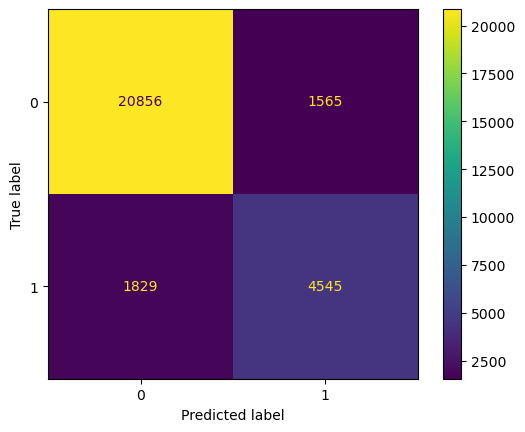

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.92     22421
           1       0.74      0.71      0.73      6374

    accuracy                           0.88     28795
   macro avg       0.83      0.82      0.83     28795
weighted avg       0.88      0.88      0.88     28795



In [54]:
y_pred = log_model.predict(X_train_status)

# evaluate
accuracy = accuracy_score(y_train, y_pred)
print(f'Training Accuracy: {accuracy:.4f}\n')

cm = confusion_matrix(y_train, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = log_model.classes_)
disp.plot()
plt.show()

report = classification_report(y_train, y_pred)
print(f'Classification Report:\n{report}')

In [55]:
# get the feature coefficients
features = X_train_status.columns
coefficients = log_model.coef_[0]

# print coefficients with feature names
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': coefficients})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

print("Feature Importance (Top):")
print(coef_df)

Feature Importance (Top):
                Feature  Coefficient
1         Interest Rate     0.934433
2  Percentage of Income     0.829022
4   Home Ownership_RENT     0.006101
5   Loan Intent_VENTURE    -0.063918
0                Income    -0.467259
3              Defaults    -4.327061


In [56]:
y_pred_prob = log_model.predict_proba(X_train_status)[:, 1]

# find ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_train, y_pred_prob)
roc_auc = auc(fpr, tpr)

# create thresholds dataframe
thresholds_df = pd.DataFrame({
    'Threshold': thresholds,
    'FPR': fpr,
    'TPR': tpr})

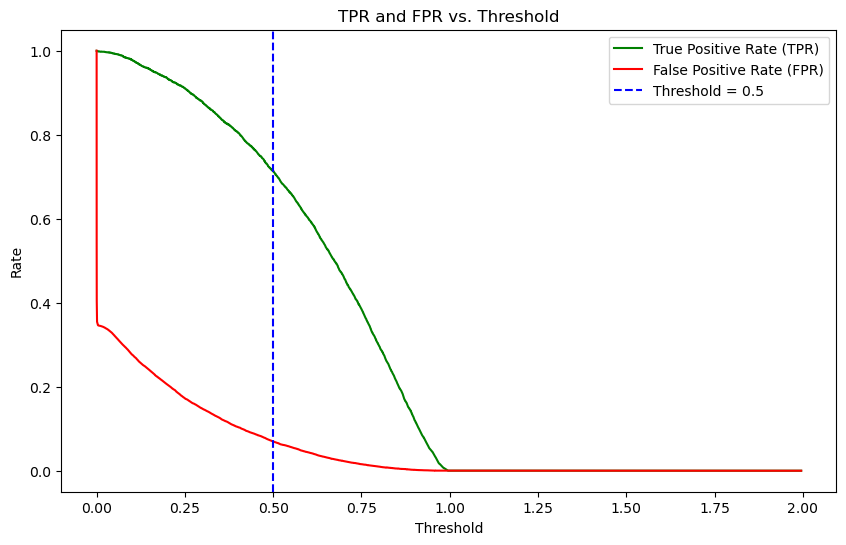

In [57]:
# Plot TPR and FPR vs. Threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds, tpr, label = 'True Positive Rate (TPR)', color = 'green')
plt.plot(thresholds, fpr, label = 'False Positive Rate (FPR)', color = 'red')
plt.axvline(x=0.5, color = 'blue', linestyle = '--', label = 'Threshold = 0.5')
plt.xlabel('Threshold')
plt.ylabel('Rate')
plt.title('TPR and FPR vs. Threshold')
plt.legend(loc = 'best')
plt.show()

In [58]:
# find optimum threshold (2 methods)
# Youden's J statistic
j = tpr - fpr

optimal_j = np.argmax(j)
threshold_j = thresholds[optimal_j]

print(f"Optimal Threshold (Youden's J): {threshold_j:.2f}")
print(f"TPR: {tpr[optimal_j]:.2f}, FPR: {fpr[optimal_j]:.2f}")

Optimal Threshold (Youden's J): 0.25
TPR: 0.91, FPR: 0.18


In [59]:
# Minimize distance to top left corner
d = np.sqrt((1 - tpr)**2 + fpr**2)

optimal_d = np.argmin(d)
threshold_d = thresholds[optimal_d]

print(f"Optimal Threshold (Youden's J): {threshold_d:.2f}")
print(f"TPR: {tpr[optimal_d]:.2f}, FPR: {fpr[optimal_d]:.2f}")

Optimal Threshold (Youden's J): 0.29
TPR: 0.88, FPR: 0.15


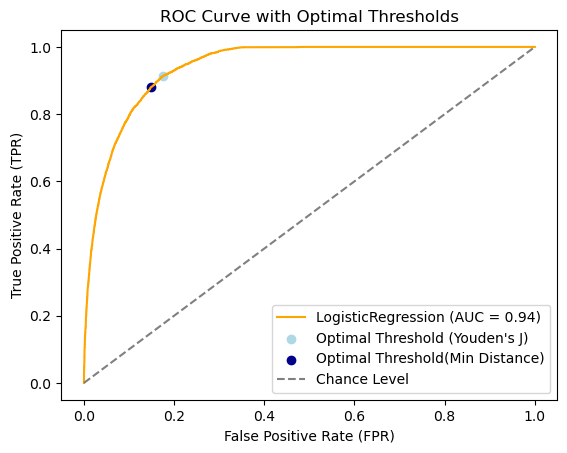

In [60]:
# graph ROC curve
RocCurveDisplay.from_estimator(log_model, X_train_status, y_train, color = 'orange')
plt.scatter(fpr[optimal_j], tpr[optimal_j], color = 'lightblue', label = "Optimal Threshold (Youden's J)")
plt.scatter(fpr[optimal_d], tpr[optimal_d], color = 'darkblue', label = 'Optimal Threshold(Min Distance)')
plt.plot([0, 1], [0, 1], linestyle = '--', color = 'gray', label = 'Chance Level')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve with Optimal Thresholds')
plt.legend()
plt.show()

## Validate Model

Training Accuracy: 0.8579



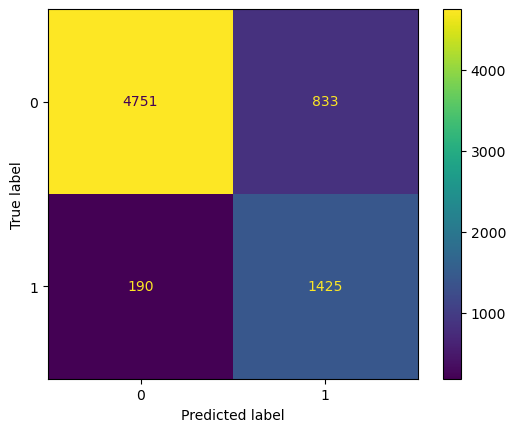

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.85      0.90      5584
           1       0.63      0.88      0.74      1615

    accuracy                           0.86      7199
   macro avg       0.80      0.87      0.82      7199
weighted avg       0.89      0.86      0.87      7199



In [61]:
y_val_prob = log_model.predict_proba(X_val_status)[:,1]

# set threshold of 0.29
tuned_threshold = 0.29
y_val_pred = (y_val_prob >= tuned_threshold).astype(int)

# evaluate
accuracy = accuracy_score(y_val, y_val_pred)
print(f'Training Accuracy: {accuracy:.4f}\n')

cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = log_model.classes_)
disp.plot()
plt.show()

report = classification_report(y_val, y_val_pred)
print(f'Classification Report:\n{report}')

Training Accuracy: 0.8793



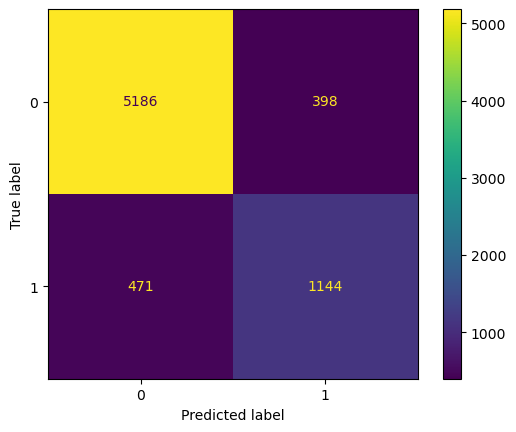

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.92      5584
           1       0.74      0.71      0.72      1615

    accuracy                           0.88      7199
   macro avg       0.83      0.82      0.82      7199
weighted avg       0.88      0.88      0.88      7199



In [62]:
y_val_pred = log_model.predict(X_val_status)

# evaluate
accuracy = accuracy_score(y_val, y_val_pred)
print(f'Training Accuracy: {accuracy:.4f}\n')

cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = log_model.classes_)
disp.plot()
plt.show()

report = classification_report(y_val, y_val_pred)
print(f'Classification Report:\n{report}')

In [63]:
# test c values
C_values = [0.01, 0.1, 1, 10, 100, 200]
for c in C_values:
    log_model = LogisticRegression(C = c, random_state = 42)
    scores = cross_val_score(log_model, X_train_status, y_train, cv = 5, scoring = 'accuracy')
    print(f'C = {c}, Mean Cross Validation Accuracy = {scores.mean():.4f}\n')

C = 0.01, Mean Cross Validation Accuracy = 0.8819

C = 0.1, Mean Cross Validation Accuracy = 0.8818

C = 1, Mean Cross Validation Accuracy = 0.8817

C = 10, Mean Cross Validation Accuracy = 0.8818

C = 100, Mean Cross Validation Accuracy = 0.8818

C = 200, Mean Cross Validation Accuracy = 0.8818



In [64]:
# update model with a c value of 100
log_model_tuned = LogisticRegression(C = 100, random_state = 11)
log_model_tuned.fit(X_train_status, y_train)

LogisticRegression(C=100, random_state=11)

## Test Model

In [65]:
y_test_pred = log_model_tuned.predict(X_test_status)
print(f'Test Accuracy (Logistic Regression): {accuracy_score(y_test, y_test_pred):.4f}')

Test Accuracy (Logistic Regression): 0.8775


# Support Vector Classification (Status Prediction)

In [66]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

## Train Model

In [67]:
# fit SVC model
svc_model = SVC(probability = True, random_state = 11)
svc_model.fit(X_train_status, y_train)

SVC(probability=True, random_state=11)

Training Accuracy: 0.8985



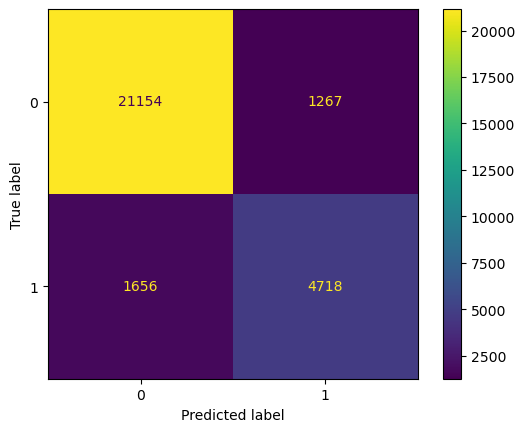

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.94     22421
           1       0.79      0.74      0.76      6374

    accuracy                           0.90     28795
   macro avg       0.86      0.84      0.85     28795
weighted avg       0.90      0.90      0.90     28795



In [68]:
y_pred = svc_model.predict(X_train_status)

# evaluate
accuracy = accuracy_score(y_train, y_pred)
print(f'Training Accuracy: {accuracy:.4f}\n')

cm = confusion_matrix(y_train, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = svc_model.classes_)
disp.plot()
plt.show()

report = classification_report(y_train, y_pred)
print(f'Classification Report:\n{report}')

In [69]:
# Define hyperparameter grid
grid = {'C': [0.1, 10, 100],
        'kernel': ['linear', 'rbf', 'poly']}

# Grid search with GPU-accelerated SVC
grid_search = GridSearchCV(SVC(probability = True), grid, cv = 5, scoring = 'accuracy')
grid_search.fit(X_train_status, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'C': 100, 'kernel': 'rbf'}


## Validate Model

In [70]:
svc_model_tuned = grid_search.best_estimator_

Training Accuracy: 0.8975



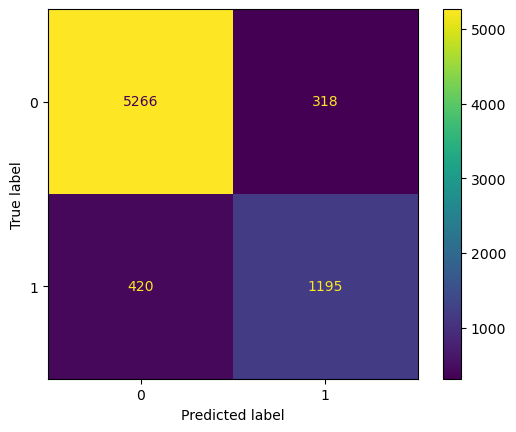

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      5584
           1       0.79      0.74      0.76      1615

    accuracy                           0.90      7199
   macro avg       0.86      0.84      0.85      7199
weighted avg       0.90      0.90      0.90      7199



In [71]:
y_val_pred = svc_model_tuned.predict(X_val_status)

# evaluate
accuracy = accuracy_score(y_val, y_val_pred)
print(f'Training Accuracy: {accuracy:.4f}\n')

cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = svc_model.classes_)
disp.plot()
plt.show()

report = classification_report(y_val, y_val_pred)
print(f'Classification Report:\n{report}')

## Test Model

In [72]:
y_test_pred = svc_model_tuned.predict(X_test_status)
print(f'Test Accuracy: {accuracy_score(y_test, y_test_pred):.4f}')

Test Accuracy: 0.8978


# Random Forest (Status Prediction)

In [73]:
from sklearn.ensemble import RandomForestClassifier

## Train Model

In [74]:
tree_model = RandomForestClassifier(random_state = 11)

tree_model.fit(X_train_status, y_train)

RandomForestClassifier(random_state=11)

## Validate Model

Training Accuracy: 0.9007



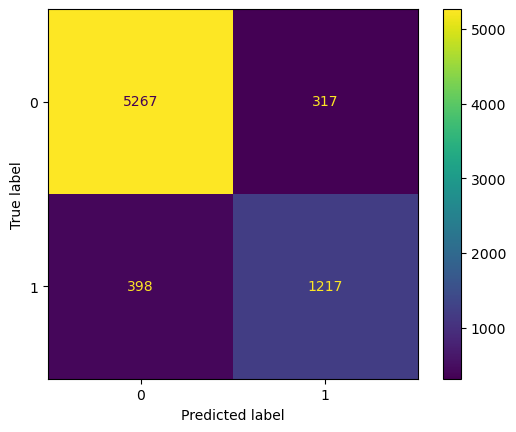

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      5584
           1       0.79      0.75      0.77      1615

    accuracy                           0.90      7199
   macro avg       0.86      0.85      0.85      7199
weighted avg       0.90      0.90      0.90      7199



In [75]:
y_pred_tree = tree_model.predict(X_val_status)

# evaluate
accuracy = accuracy_score(y_val, y_pred_tree)
print(f'Training Accuracy: {accuracy:.4f}\n')

cm = confusion_matrix(y_val, y_pred_tree)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = tree_model.classes_)
disp.plot()
plt.show()

report = classification_report(y_val, y_pred_tree)
print(f'Classification Report:\n{report}')

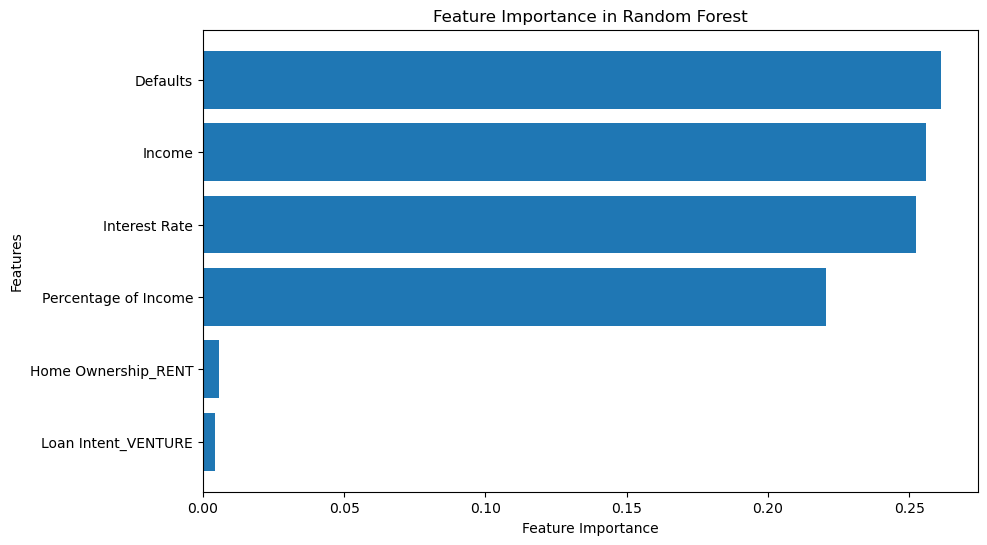

In [76]:
# investigate feature importance
feature_importance = tree_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X_val_status.columns,
    'Importance': feature_importance
}).sort_values(by = 'Importance', ascending=False)

# visualize
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance in Random Forest')
plt.gca().invert_yaxis()
plt.show()

In [77]:
# complete grid search to optimize model
grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 3, 10, 20],
    'min_samples_split': [10, 30, 100],
    'min_samples_leaf': [10, 20, 30],
    'bootstrap': [True, False]}

# Set up GridSearch
grid_search = GridSearchCV(estimator = RandomForestClassifier(random_state = 2), 
                           param_grid = grid, 
                           cv = 3, 
                           scoring = 'accuracy', 
                           verbose = 3, 
                           n_jobs = -1)

# Fit to the training data
grid_search.fit(X_train_status, y_train)

# Best parameters
print(f"Best parameters: {grid_search.best_params_}")
tree_model_tuned = grid_search.best_estimator_

Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best parameters: {'bootstrap': True, 'max_depth': 20, 'min_samples_leaf': 10, 'min_samples_split': 10, 'n_estimators': 100}


## Test Model

In [78]:
# predict using the hyperparameters determined above
y_pred_test_tree = tree_model_tuned.predict(X_test_status)

# evaluate
accuracy = accuracy_score(y_test, y_pred_test_tree)
print(f'Testing Accuracy: {accuracy:.4f}\n')

Testing Accuracy: 0.9030



# Compare Models (Status Prediction)

In [79]:
# calculate AUC for each
y_pred_prob_log = log_model_tuned.predict_proba(X_test_status)[:, 1]
y_pred_prob_svc = svc_model_tuned.predict_proba(X_test_status)[:, 1]
y_pred_prob_tree = tree_model_tuned.predict_proba(X_test_status)[:, 1]

# find AUC
fpr_log, tpr_log, thresholds_log = roc_curve(y_test, y_pred_prob_log)
log_auc = auc(fpr_log, tpr_log)

fpr_svc, tpr_svc, thresholds_svc = roc_curve(y_test, y_pred_prob_svc)
svc_auc = auc(fpr_svc, tpr_svc)

fpr_tree, tpr_tree, thresholds_tree = roc_curve(y_test, y_pred_prob_tree)
tree_auc = auc(fpr_tree, tpr_tree)

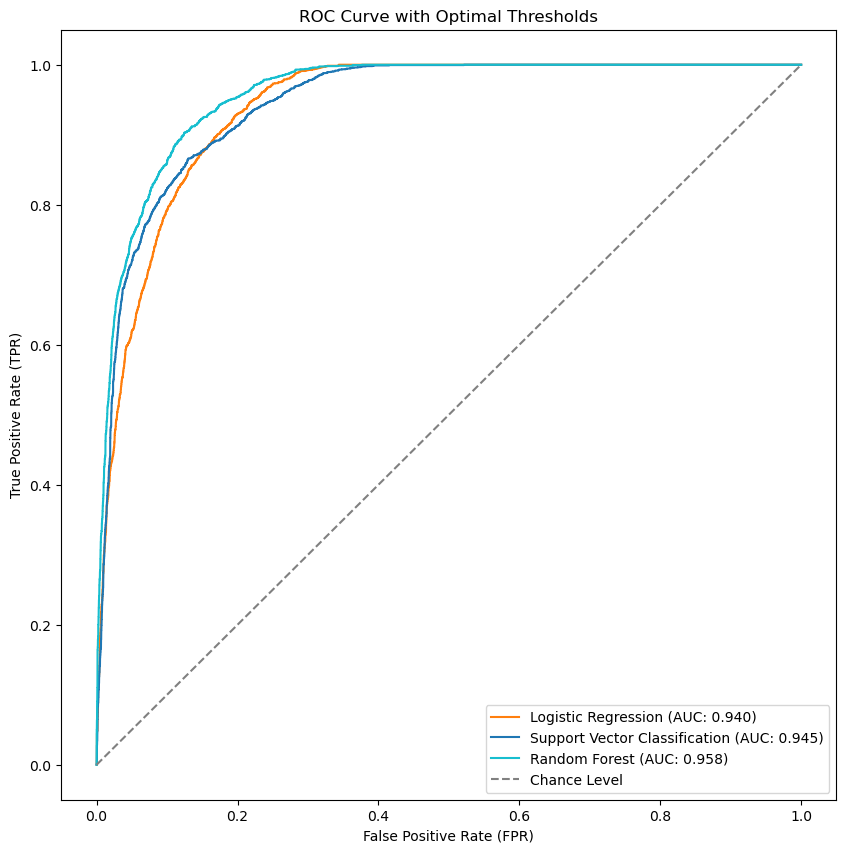

In [80]:
# graph ROC curves
fig, ax = plt.subplots(figsize = (10, 10))

# logistic regression
RocCurveDisplay.from_estimator(log_model_tuned, X_test_status, y_test, color = '#FF7F0E', 
                               label = f'Logistic Regression (AUC: {log_auc:.3f})', ax = ax)
# SVC
RocCurveDisplay.from_estimator(svc_model_tuned, X_test_status, y_test, color = '#1F77B4', 
                               label = f'Support Vector Classification (AUC: {svc_auc:.3f})', ax = ax)
# Random Forest
RocCurveDisplay.from_estimator(tree_model_tuned, X_test_status, y_test, color = '#17BECF', 
                               label = f'Random Forest (AUC: {tree_auc:.3f})', ax = ax)

plt.plot([0, 1], [0, 1], linestyle = '--', color = 'gray', label = 'Chance Level')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve with Optimal Thresholds')
plt.legend()
plt.show()

# Linear Regression Model (Credit Score Prediction FAILED CONJECTURE)

In [81]:
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [82]:
df_lin = df.drop(columns=['Status', 'Percentage of Income', 'Interest Rate', 'Loan Intent', 'Loan Amount'])
categorical_cols = ['Defaults', 'Home Ownership', 'Sex', 'Education Level']

# Create a LabelEncoder object
le = LabelEncoder()

# Encode the categorical columns
for col in categorical_cols:
    df_lin[col] = le.fit_transform(df_lin[col])

df_lin.head()

,Age,Sex,Education Level,Income,Employment Years,Home Ownership,Years of Credit History,Credit Score,Defaults
0,22.0,0,4,71948.0,0,3,3.0,561,0
1,21.0,0,3,12282.0,0,2,2.0,504,1
2,25.0,0,3,12438.0,3,0,3.0,635,0
3,23.0,0,1,79753.0,0,3,2.0,675,0
4,24.0,1,4,66135.0,1,3,4.0,586,0


In [83]:
X = df_lin.drop('Credit Score', axis=1)
y = (df_lin['Credit Score'])

# Split the data into training and testing sets
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(X, y, test_size=0.1)

# Create a linear regression model
lin_model = LinearRegression()

# Train the model on the training data
lin_model.fit(X_train_lin, y_train_lin)

# Make predictions on the testing data
y_pred_lin = lin_model.predict(X_test_lin)

# Evaluate the model's performance
mse = mean_squared_error(y_test_lin, y_pred_lin)
print("Mean Squared Error:", mse)

r2 = r2_score(y_test_lin, y_pred_lin)

print("R-squared:", r2)

Mean Squared Error: 2413.739726652929
R-squared: 0.06492754366073084


In [84]:
for feature, coef in zip(X.columns, lin_model.coef_):
    print(f"{feature:30} {coef:2f}")

Age                            0.014295
Sex                            -0.163464
Education Level                0.510098
Income                         0.000009
Employment Years               1.445083
Home Ownership                 -0.682967
Years of Credit History        0.068884
Defaults                       -18.233169
